In [85]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


## Environment Setup

In [143]:
!pip install torch_geometric

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [144]:
# Install required libraries if not already present
# !pip install torch torch_geometric scikit-learn matplotlib seaborn networkx tqdm

import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')

# ── Plot style ──
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

PyTorch version : 2.9.0+cu126
Device          : cuda


---
<a id='step1'></a>
## Step 1 — Download & Inspect Dataset

The dataset is already stored locally under `elliptic_bitcoin_dataset/`.  
Three files:
| File | Description |
|------|-------------|
| `elliptic_txs_features.csv` | 203,769 rows × 167 cols (txId + timestep + 165 features) |
| `elliptic_txs_edgelist.csv` | 234,355 directed edges (txId1 → txId2) |
| `elliptic_txs_classes.csv`  | Per-transaction label: `1`=illicit, `2`=licit, `unknown` |

# ── Paths ──
DATA_DIR   = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"
FEAT_PATH  = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv"
EDGE_PATH  = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv"
CLASS_PATH = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv"

# ── Load ──
# Features file has NO header; columns are: txId, timestep, f1..f165
feat_cols = ['txId', 'timestep'] + [f'f{i}' for i in range(1, 166)]
df_feat   = pd.read_csv(FEAT_PATH,  header=None, names=feat_cols)
df_edges  = pd.read_csv(EDGE_PATH)
df_cls    = pd.read_csv(CLASS_PATH)

print('=== Features ===' )
print(f'  Shape : {df_feat.shape}')
print(f'  txId range : {df_feat.txId.min()} – {df_feat.txId.max()}')
print(f'  Timesteps  : {sorted(df_feat.timestep.unique())[:5]} … {sorted(df_feat.timestep.unique())[-3:]}')
print(f'  Nulls      : {df_feat.isnull().sum().sum()}')
print()
print('=== Edge list ===')
print(f'  Shape : {df_edges.shape}')
print(f'  Nulls : {df_edges.isnull().sum().sum()}')
print()
print('=== Classes ===')
print(f'  Shape : {df_cls.shape}')
print(df_cls['class'].value_counts())

---
<a id='step2'></a>
## Step 2 — Exploratory Data Analysis (EDA)

Key things to understand before modelling:
- **Class imbalance** — only ~2 % of labeled transactions are illicit.
- **Temporal structure** — 49 time steps; fraud patterns shift over time (*concept drift*).
- **Feature groups** — first 94 are *local* node features; last 72 are *aggregated structural* features.
- **Graph topology** — degree distribution, connected components, etc.

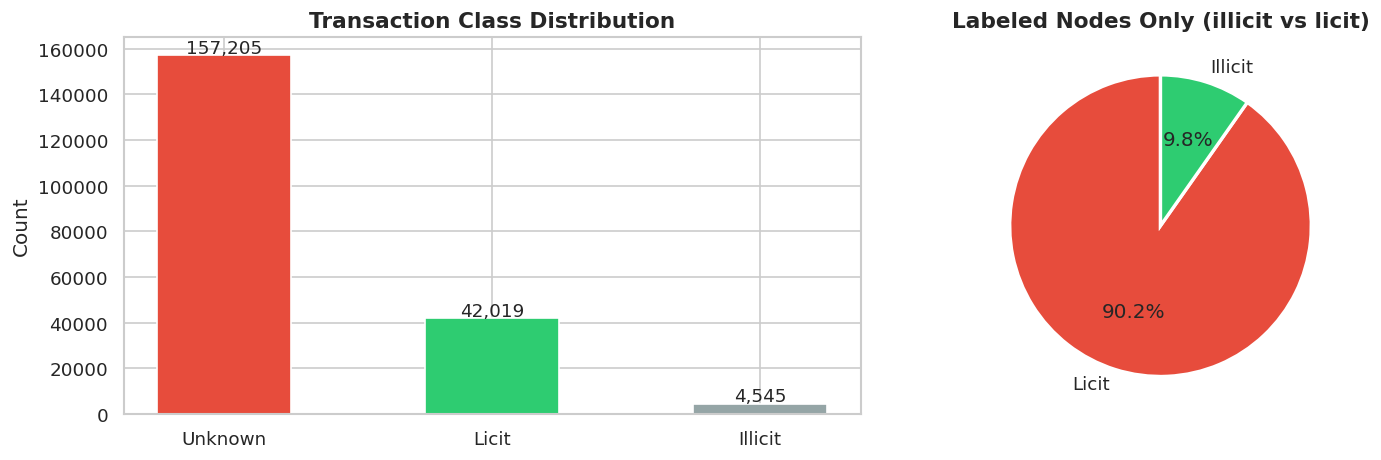

Total labeled   : 46,564
  Illicit       : 4,545  (9.8%)
  Licit         : 42,019  (90.2%)
Unlabeled (unk) : 157,205


In [145]:
# 2-A: Overall class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

class_counts = df_cls['class'].value_counts()
label_map    = {'1': 'Illicit', '2': 'Licit', 'unknown': 'Unknown'}
labels_nice  = [label_map.get(str(k), str(k)) for k in class_counts.index]
colors       = ['#E74C3C', '#2ECC71', '#95A5A6']

# Bar chart
axes[0].bar(labels_nice, class_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Transaction Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

# Pie (labeled-only)
labeled = df_cls[df_cls['class'] != 'unknown']
lc = labeled['class'].value_counts()
axes[1].pie(
    lc.values,
    labels=[label_map.get(str(k)) for k in lc.index],
    autopct='%1.1f%%',
    colors=['#E74C3C', '#2ECC71'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Labeled Nodes Only (illicit vs licit)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight')
plt.show()
print(f'Total labeled   : {len(labeled):,}')
print(f'  Illicit       : {(lc.get("1", lc.get(1, 0))):,}  ({(lc.get("1", lc.get(1, 0))/len(labeled)*100):.1f}%)')
print(f'  Licit         : {(lc.get("2", lc.get(2, 0))):,}  ({(lc.get("2", lc.get(2, 0))/len(labeled)*100):.1f}%)')
print(f'Unlabeled (unk) : {(df_cls["class"]=="unknown").sum():,}')

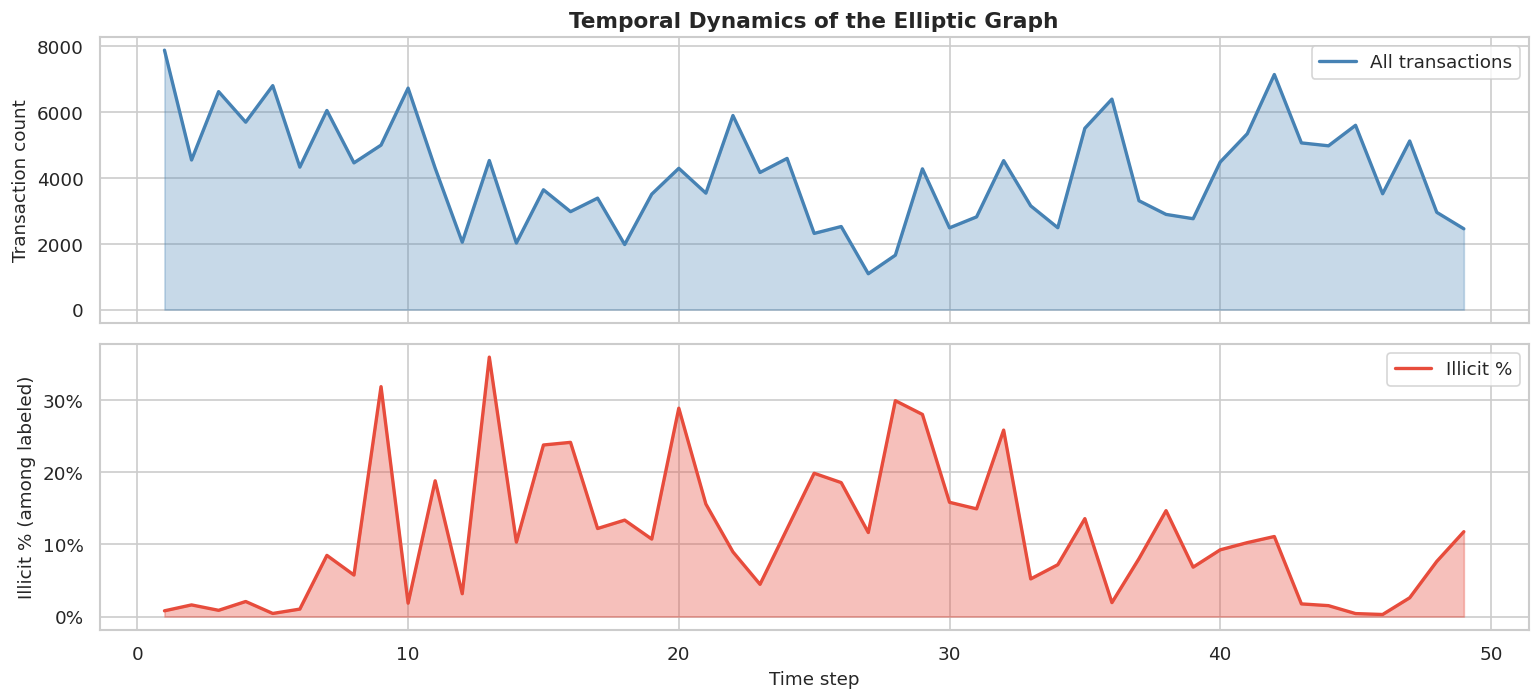

Concept drift is visible — illicit fraction fluctuates significantly across time steps.


In [146]:
# 2-B: Temporal dynamics — transaction counts and illicit fraction per time step
merged_ts = df_feat[['txId', 'timestep']].merge(df_cls, on='txId', how='left')

ts_total   = merged_ts.groupby('timestep').size()
ts_illicit = merged_ts[merged_ts['class'] == '1'].groupby('timestep').size()
ts_licit   = merged_ts[merged_ts['class'] == '2'].groupby('timestep').size()
ts_illicit_frac = (ts_illicit / (ts_illicit.add(ts_licit, fill_value=0))).fillna(0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax1.fill_between(ts_total.index, ts_total.values, alpha=0.3, color='steelblue')
ax1.plot(ts_total.index, ts_total.values, color='steelblue', linewidth=2, label='All transactions')
ax1.set_ylabel('Transaction count', fontsize=11)
ax1.set_title('Temporal Dynamics of the Elliptic Graph', fontsize=13, fontweight='bold')
ax1.legend()

ax2.fill_between(ts_illicit_frac.index, ts_illicit_frac.values * 100, alpha=0.35, color='#E74C3C')
ax2.plot(ts_illicit_frac.index, ts_illicit_frac.values * 100, color='#E74C3C', linewidth=2, label='Illicit %')
ax2.set_ylabel('Illicit % (among labeled)', fontsize=11)
ax2.set_xlabel('Time step', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend()

plt.tight_layout()
plt.savefig('eda_temporal_dynamics.png', bbox_inches='tight')
plt.show()
print('Concept drift is visible — illicit fraction fluctuates significantly across time steps.')

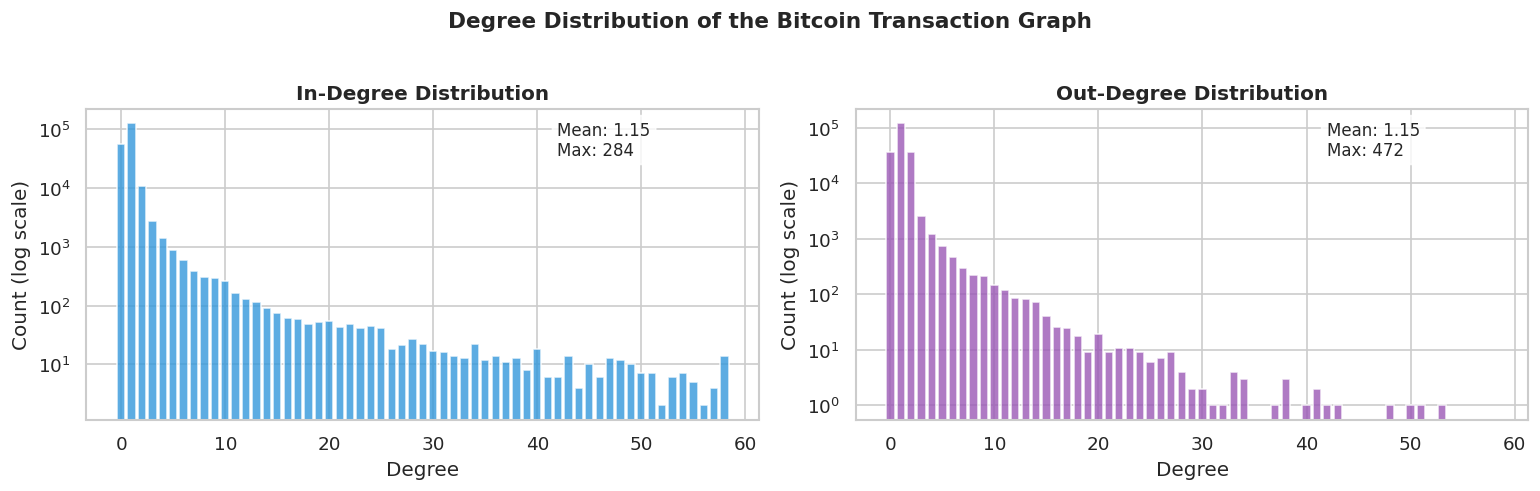

Nodes              : 203,769
Edges              : 234,355
Connected components: 49
Largest component  : 7,880 nodes
Mean in-degree     : 1.1501
Mean out-degree    : 1.1501


In [147]:
# 2-C: Graph statistics — degree distribution
G = nx.from_pandas_edgelist(df_edges, source='txId1', target='txId2',
                             create_using=nx.DiGraph())

in_degrees  = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, deg, title, color in zip(
    axes,
    [in_degrees, out_degrees],
    ['In-Degree Distribution', 'Out-Degree Distribution'],
    ['#3498DB', '#9B59B6']
):
    vals, bins = np.histogram(deg, bins=range(0, min(max(deg)+2, 60)))
    ax.bar(bins[:-1], vals, color=color, alpha=0.8, edgecolor='white')
    ax.set_yscale('log')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Count (log scale)')
    ax.text(0.7, 0.85, f'Mean: {np.mean(deg):.2f}\nMax: {max(deg)}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Degree Distribution of the Bitcoin Transaction Graph', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_degree_distribution.png', bbox_inches='tight')
plt.show()

# Connected components
undirected_G = G.to_undirected()
components   = list(nx.connected_components(undirected_G))
print(f'Nodes              : {G.number_of_nodes():,}')
print(f'Edges              : {G.number_of_edges():,}')
print(f'Connected components: {len(components):,}')
print(f'Largest component  : {max(len(c) for c in components):,} nodes')
print(f'Mean in-degree     : {np.mean(in_degrees):.4f}')
print(f'Mean out-degree    : {np.mean(out_degrees):.4f}')

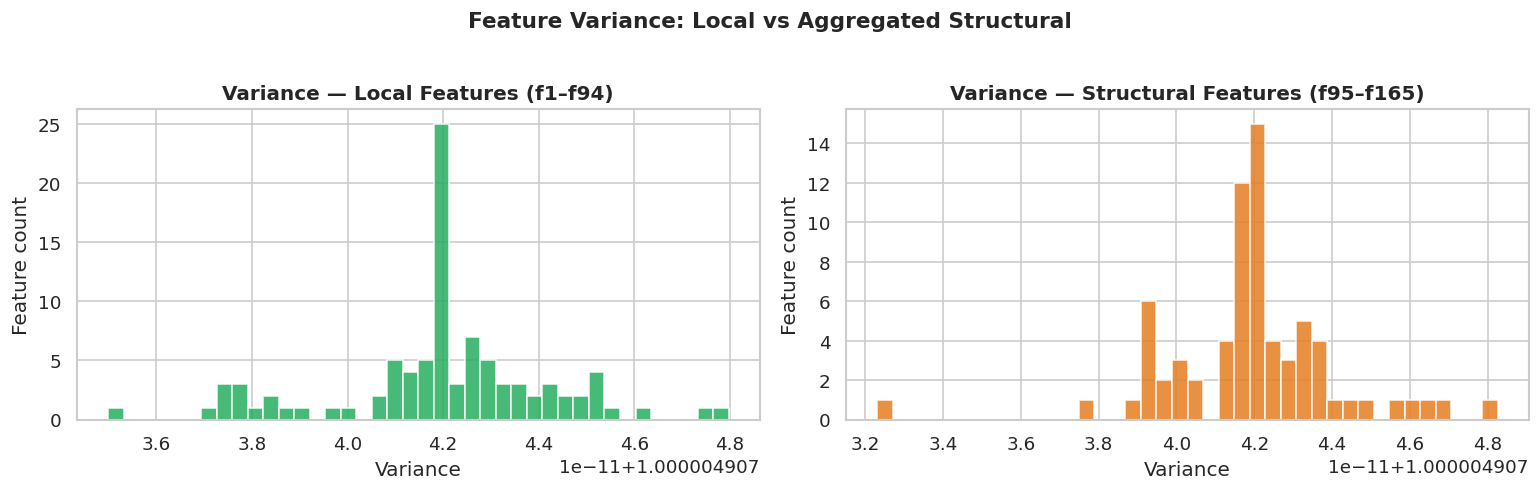

Local features    : 94 (f1–f94)
Structural feats  : 71 (f95–f165)
Mean local var    : 1.0000
Mean struct var   : 1.0000


In [148]:
# 2-D: Local (f1–f94) vs Structural (f95–f165) feature analysis
local_cols = [f'f{i}' for i in range(1, 95)]
struct_cols = [f'f{i}' for i in range(95, 166)]

local_vars  = df_feat[local_cols].var()
struct_vars = df_feat[struct_cols].var()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(local_vars, bins=40, color='#27AE60', alpha=0.85, edgecolor='white')
axes[0].set_title('Variance — Local Features (f1–f94)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Variance')
axes[0].set_ylabel('Feature count')

axes[1].hist(struct_vars, bins=40, color='#E67E22', alpha=0.85, edgecolor='white')
axes[1].set_title('Variance — Structural Features (f95–f165)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Variance')
axes[1].set_ylabel('Feature count')

plt.suptitle('Feature Variance: Local vs Aggregated Structural', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_variance.png', bbox_inches='tight')
plt.show()
print(f'Local features    : {len(local_cols)} (f1–f94)')
print(f'Structural feats  : {len(struct_cols)} (f95–f165)')
print(f'Mean local var    : {local_vars.mean():.4f}')
print(f'Mean struct var   : {struct_vars.mean():.4f}')

---
<a id='step3'></a>
## Step 3 — Preprocessing & Graph Construction

Steps:
1. Map raw class labels `1 → illicit (1)`, `2 → licit (0)`, `unknown → -1`.
2. Normalize all 166 node features with `StandardScaler`.
3. Prepare **two** feature variants:
   - **Full (166 features):** local + structural — used by all teams for their primary models.
   - **Ablated (94 features):** local only — for Team 2's ablation study.
4. Build `torch_geometric.data.Data` objects with `train_mask` / `val_mask` / `test_mask` (labeled nodes only).
5. Save `.pt` files for handoff to Teams 2 & 3 by **Mar 12**.

In [149]:
# ── 3-A: Merge features + classes ──
df_merged = df_feat.merge(df_cls, on='txId', how='left')
df_merged['class'] = df_merged['class'].fillna('unknown')

# Map: 1 → illicit=1, 2 → licit=0, unknown → -1
label_encode = {'1': 1, '2': 0, 'unknown': -1}
df_merged['label'] = df_merged['class'].astype(str).map(label_encode)

# Assign sequential integer indices (node IDs for edge_index)
df_merged = df_merged.reset_index(drop=True)
txid_to_idx = {txid: idx for idx, txid in enumerate(df_merged['txId'])}

print(f'Merged dataframe shape : {df_merged.shape}')
print(f'Label distribution     :\n{df_merged["label"].value_counts().to_string()}')

Merged dataframe shape : (203769, 169)
Label distribution     :
label
-1    157205
 0     42019
 1      4545


In [150]:
# ── 3-B: Feature normalization ──
feature_cols = [f'f{i}' for i in range(1, 166)]   # 165 features (timestep excluded as feature)
# NOTE: the dataset has 165 true financial features; timestep is metadata not a model input.
# Double-check column count:
print(f'Number of feature columns used: {len(feature_cols)}')

X_raw = df_merged[feature_cols].values.astype(np.float32)

scaler       = StandardScaler()
X_full_norm  = scaler.fit_transform(X_raw)             # 165 features (all)

# Local-only variant: first 94 features (f1–f94)
local_cols_idx = slice(0, 94)
scaler_local   = StandardScaler()
X_local_norm   = scaler_local.fit_transform(X_raw[:, local_cols_idx])   # 94 features

print(f'Full feature matrix  : {X_full_norm.shape}')
print(f'Local feature matrix : {X_local_norm.shape}')

Number of feature columns used: 165
Full feature matrix  : (203769, 165)
Local feature matrix : (203769, 94)


In [95]:
# ── 3-C: Build edge_index ──
# Filter edges to only keep nodes that exist in our feature matrix
valid_src = df_edges['txId1'].isin(txid_to_idx)
valid_dst = df_edges['txId2'].isin(txid_to_idx)
df_edges_clean = df_edges[valid_src & valid_dst].copy()

src = df_edges_clean['txId1'].map(txid_to_idx).values
dst = df_edges_clean['txId2'].map(txid_to_idx).values
edge_index = torch.tensor(np.stack([src, dst], axis=0), dtype=torch.long)

print(f'Edge index shape : {edge_index.shape}  (2 × E)')
print(f'Edges kept       : {edge_index.shape[1]:,}  (out of {len(df_edges):,})')

Edge index shape : torch.Size([2, 234355])  (2 × E)
Edges kept       : 234,355  (out of 234,355)


In [151]:
df_merged.head()

,txId,timestep,f1,f2,f3,f4,f5,f6,f7,f8,...,f158,f159,f160,f161,f162,f163,f164,f165,class,label
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,-1
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,-1
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown,-1
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2,0
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown,-1


In [152]:
# ── 3-D: Build masks — train/val/test split (labeled nodes only) ──
labels = torch.tensor(df_merged['label'].values, dtype=torch.long)
labeled_mask = labels != -1       # only labeled nodes participate in loss
labeled_idx  = labeled_mask.nonzero(as_tuple=True)[0]

# Temporal split: first 34 timesteps → train/val; last 15 → test
timestep_arr = df_merged['timestep'].values
TRAIN_TS_MAX = 34

train_val_labeled = labeled_idx[(torch.tensor(timestep_arr)[labeled_idx] <= TRAIN_TS_MAX)]
test_labeled      = labeled_idx[(torch.tensor(timestep_arr)[labeled_idx] >  TRAIN_TS_MAX)]

# 80/20 train–val split within train_val_labeled
perm       = torch.randperm(len(train_val_labeled), generator=torch.Generator().manual_seed(SEED))
n_train    = int(0.8 * len(train_val_labeled))
train_idx  = train_val_labeled[perm[:n_train]]
val_idx    = train_val_labeled[perm[n_train:]]

N = len(df_merged)
train_mask = torch.zeros(N, dtype=torch.bool);  train_mask[train_idx] = True
val_mask   = torch.zeros(N, dtype=torch.bool);  val_mask[val_idx]     = True
test_mask  = torch.zeros(N, dtype=torch.bool);  test_mask[test_labeled] = True

print(f'Total nodes   : {N:,}')
print(f'Labeled nodes : {labeled_mask.sum().item():,}')
print(f'  Train       : {train_mask.sum().item():,}')
print(f'  Val         : {val_mask.sum().item():,}')
print(f'  Test        : {test_mask.sum().item():,}')

Total nodes   : 203,769
Labeled nodes : 46,564
  Train       : 23,915
  Val         : 5,979
  Test        : 16,670


In [98]:
# ── 3-E: Create PyG Data objects and save ──
x_full  = torch.tensor(X_full_norm,  dtype=torch.float)
x_local = torch.tensor(X_local_norm, dtype=torch.float)

data_full = Data(
    x          = x_full,
    edge_index = edge_index,
    y          = labels,
    train_mask = train_mask,
    val_mask   = val_mask,
    test_mask  = test_mask
)

data_ablated = Data(
    x          = x_local,
    edge_index = edge_index,
    y          = labels,
    train_mask = train_mask,
    val_mask   = val_mask,
    test_mask  = test_mask
)

torch.save(data_full,    'elliptic_full.pt')
torch.save(data_ablated, 'elliptic_ablated.pt')

print('Saved: elliptic_full.pt    →', data_full)
print('Saved: elliptic_ablated.pt →', data_ablated)

Saved: elliptic_full.pt    → Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Saved: elliptic_ablated.pt → Data(x=[203769, 94], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


---
<a id='step4'></a>
## Step 4 — GCN Definition & Training

**Architecture:**
```
GCNConv(166 → 128) → ReLU → Dropout(0.3)
GCNConv(128 → 2)  → ReLU → Dropout(0.3)
```

**Training setup:**
- Optimizer: `Adam` (lr=0.001, weight_decay=5e-4) + `ReduceLROnPlateau` scheduler
- Loss: `FocalLoss` (α=**0.75**, γ=2.0) — `alpha=0.75` **strongly favours the illicit minority class**  
  *(implemented here inline; will be shared with Teams 2 & 3 via Team 2's shared utilities cell)*
- Max **500** epochs; early stopping on validation F1 (patience=**50**)
- Full-batch GCN (entire graph in one forward pass)
- **Threshold calibration** after training — sweep decision threshold on val set instead of fixed 0.5

In [99]:
# ── Focal Loss — addresses class imbalance ──
# Only ~2% of labeled nodes are illicit; standard cross-entropy under-penalises
# errors on the minority class.  Focal Loss down-weights easy examples and
# focuses training on hard-to-classify (illicit) transactions.
class FocalLoss(nn.Module):
    """
    Focal Loss: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    alpha : class weighting factor (default 0.25 for minority class)
    gamma : focusing parameter (default 2.0)
    """
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # logits: (N, C),  targets: (N,)  — only labeled (0/1) nodes are passed
        ce_loss  = F.cross_entropy(logits, targets, reduction='none')
        p_t      = torch.exp(-ce_loss)          # probability of correct class
        alpha_t  = self.alpha * targets + (1 - self.alpha) * (1 - targets)  # per-sample alpha
        fl       = alpha_t * (1 - p_t) ** self.gamma * ce_loss
        return fl.mean() if self.reduction == 'mean' else fl.sum()


# Quick test
dummy_logits  = torch.randn(5, 2)
dummy_targets = torch.randint(0, 2, (5,))
fl_test = FocalLoss()(dummy_logits, dummy_targets)
print(f'FocalLoss test value: {fl_test.item():.4f}  ✓')

FocalLoss test value: 0.1809  ✓


In [100]:
# ── GCN Model ──
class GCN(nn.Module):
    """2-layer Graph Convolutional Network (Kipf & Welling 2017)."""
    def __init__(self, in_channels, hidden=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1   = GCNConv(in_channels, hidden)
        self.conv2   = GCNConv(hidden, num_classes)
        self.dp      = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dp, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

    def reset_parameters(self):
        self.conv1.reset_parameters()
        self.conv2.reset_parameters()




# Instantiate for full (165-feature) data
model = GCN(in_channels=data_full.num_features).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

GCN(
  (conv1): GCNConv(165, 128)
  (conv2): GCNConv(128, 2)
)

Trainable parameters: 21,506


In [101]:
# ── Training utilities ──
class EarlyStopping:
    """Stop training when validation F1 has not improved for `patience` epochs."""
    def __init__(self, patience: int = 20, path: str = 'gcn_checkpoint.pt'):
        self.patience   = patience
        self.path       = path
        self.best_score = None
        self.counter    = 0
        self.stop       = False

    def __call__(self, val_f1: float, model: nn.Module):
        if self.best_score is None or val_f1 > self.best_score:
            self.best_score = val_f1
            self.counter    = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


@torch.no_grad()
def evaluate(model: nn.Module, data: Data, mask: torch.Tensor, device):
    """Return loss, accuracy, F1, precision, recall, PR-AUC on `mask`."""
    model.eval()
    logits = model(data.x.to(device), data.edge_index.to(device))
    mask_d = mask.to(device)
    y_true = data.y[mask].to(device)

    loss_fn = FocalLoss()
    loss = loss_fn(logits[mask_d], y_true).item()

    preds = logits[mask_d].argmax(dim=1).cpu().numpy()
    probs = F.softmax(logits[mask_d], dim=1)[:, 1].cpu().numpy()
    y_np  = y_true.cpu().numpy()

    f1        = f1_score(y_np, preds, zero_division=0)
    precision = precision_score(y_np, preds, zero_division=0)
    recall    = recall_score(y_np, preds, zero_division=0)
    try:
        pr_auc = average_precision_score(y_np, probs)
    except ValueError:
        pr_auc = 0.0

    return loss, f1, precision, recall, pr_auc


print('Training utilities defined.')

Training utilities defined.


In [102]:
# ── Training loop ──
MAX_EPOCHS   = 5000
LR         = 1e-3
WEIGHT_DECAY = 5e-4
PATIENCE     = 500

model     = GCN(in_channels=data_full.num_features).to(DEVICE)
model.reset_parameters()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# alpha=0.75: illicit nodes receive 75% of loss weight vs 25% for licit
criterion = FocalLoss(alpha=0.85, gamma=2.0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=15, min_lr=1e-5
)
stopper   = EarlyStopping(patience=PATIENCE, path='gcn_checkpoint.pt')

# Move full graph to device
data_d = data_full.to(DEVICE)

history = {'epoch': [], 'train_loss': [], 'val_loss': [],
           'train_f1': [], 'val_f1': [],
           'train_pr_auc': [], 'val_pr_auc': [],
           'lr': []}

print(f'Training GCN — max {MAX_EPOCHS} epochs, early stopping patience={PATIENCE}')
print(f'FocalLoss alpha=0.75  gamma=2.0')
print(f'Device: {DEVICE}\n')

for epoch in tqdm(range(1, MAX_EPOCHS + 1), desc='Training', unit='ep'):
    # ── train step ──
    model.train()
    optimizer.zero_grad()
    logits = model(data_d.x, data_d.edge_index)
    loss   = criterion(logits[data_d.train_mask], data_d.y[data_d.train_mask])
    loss.backward()
    optimizer.step()

    # ── evaluation ──
    tr_loss, tr_f1, tr_prec, tr_rec, tr_prauc = evaluate(model, data_full, train_mask, DEVICE)
    vl_loss, vl_f1, vl_prec, vl_rec, vl_prauc = evaluate(model, data_full, val_mask,   DEVICE)

    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)
    history['train_pr_auc'].append(tr_prauc)
    history['val_pr_auc'].append(vl_prauc)

    if epoch % 500 == 0:
        tqdm.write(
            f'Ep {epoch:3d} | lr={current_lr:.2e} | '
            f'Train Loss={tr_loss:.4f}  F1={tr_f1:.4f}  PR-AUC={tr_prauc:.4f} | '
            f'Val   Loss={vl_loss:.4f}  F1={vl_f1:.4f}  PR-AUC={vl_prauc:.4f}'
        )

    scheduler.step(vl_f1)   # reduce LR when val F1 plateaus
    current_lr = optimizer.param_groups[0]['lr']
    history['lr'].append(current_lr)

    stopper(vl_f1, model)
    if stopper.stop:
        print(f'\nEarly stopping at epoch {epoch} (best val F1={stopper.best_score:.4f})')
        break

print(f'\nBest checkpoint saved: gcn_checkpoint.pt  (Val F1 = {stopper.best_score:.4f})')

Training GCN — max 5000 epochs, early stopping patience=500
FocalLoss alpha=0.75  gamma=2.0
Device: cuda



Training:  10%|█         | 502/5000 [00:38<05:43, 13.09ep/s]

Ep 500 | lr=1.00e-05 | Train Loss=0.0304  F1=0.7497  PR-AUC=0.8763 | Val   Loss=0.0349  F1=0.7151  PR-AUC=0.8458


Training:  16%|█▋        | 813/5000 [01:01<05:17, 13.20ep/s]


Early stopping at epoch 814 (best val F1=0.7167)

Best checkpoint saved: gcn_checkpoint.pt  (Val F1 = 0.7167)


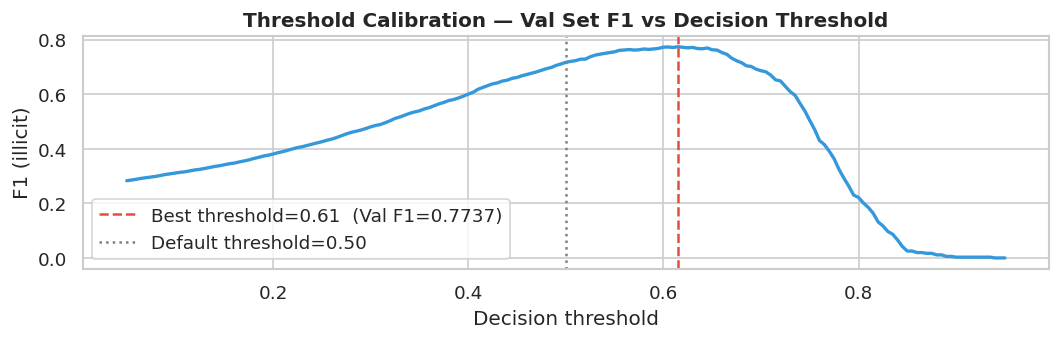

Default threshold (0.50) → Val F1 = 0.7167
Best threshold   (0.61) → Val F1 = 0.7737  ← using this for test evaluation


In [103]:
# ── 5-0: Threshold calibration on val set ──
# argmax (threshold=0.5) is suboptimal for imbalanced data.
# Sweep thresholds on the val set; pick the one that maximises illicit F1.
model.load_state_dict(torch.load('gcn_checkpoint.pt', map_location=DEVICE))
model.eval()
with torch.no_grad():
    logits_all = model(data_full.x.to(DEVICE), data_full.edge_index.to(DEVICE))
    val_probs  = F.softmax(logits_all[val_mask.to(DEVICE)], dim=1)[:, 1].cpu().numpy()
    val_true   = data_full.y[val_mask].cpu().numpy()

thresholds  = np.linspace(0.05, 0.95, 181)
f1_scores   = [f1_score(val_true, (val_probs >= t).astype(int), zero_division=0) for t in thresholds]
BEST_THRESH = thresholds[int(np.argmax(f1_scores))]
best_val_f1 = max(f1_scores)

plt.figure(figsize=(9, 3))
plt.plot(thresholds, f1_scores, color='#3498DB', linewidth=2)
plt.axvline(BEST_THRESH, color='#E74C3C', linestyle='--',
            label=f'Best threshold={BEST_THRESH:.2f}  (Val F1={best_val_f1:.4f})')
plt.axvline(0.5, color='gray', linestyle=':', label='Default threshold=0.50')
plt.title('Threshold Calibration — Val Set F1 vs Decision Threshold', fontsize=12, fontweight='bold')
plt.xlabel('Decision threshold')
plt.ylabel('F1 (illicit)')
plt.legend()
plt.tight_layout()
plt.savefig('gcn_threshold_calibration.png', bbox_inches='tight')
plt.show()
print(f'Default threshold (0.50) → Val F1 = {f1_scores[90]:.4f}')
print(f'Best threshold   ({BEST_THRESH:.2f}) → Val F1 = {best_val_f1:.4f}  ← using this for test evaluation')

---
<a id='step5'></a>
## Step 5 — Results & Evaluation Curves

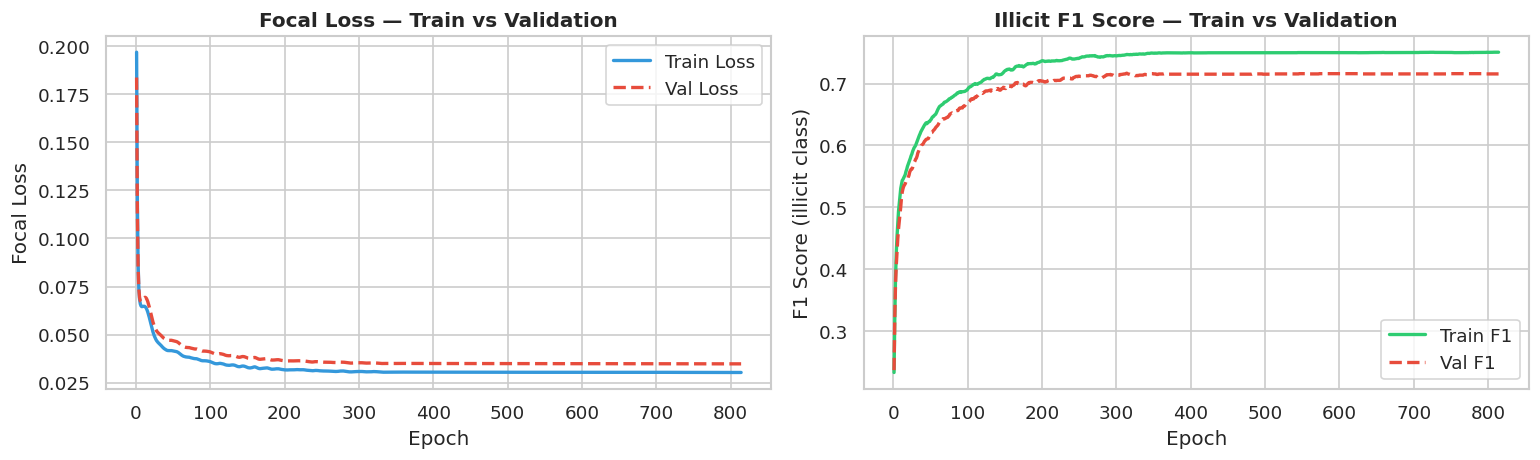

In [104]:
# ── 5-A: Loss & F1 curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs_arr = history['epoch']

ax1.plot(epochs_arr, history['train_loss'], label='Train Loss', color='#3498DB', linewidth=2)
ax1.plot(epochs_arr, history['val_loss'],   label='Val Loss',   color='#E74C3C', linewidth=2, linestyle='--')
ax1.set_title('Focal Loss — Train vs Validation', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Focal Loss')
ax1.legend()

ax2.plot(epochs_arr, history['train_f1'], label='Train F1', color='#2ECC71', linewidth=2)
ax2.plot(epochs_arr, history['val_f1'],   label='Val F1',   color='#E74C3C', linewidth=2, linestyle='--')
ax2.set_title('Illicit F1 Score — Train vs Validation', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score (illicit class)')
ax2.legend()

plt.tight_layout()
plt.savefig('gcn_loss_f1_curves.png', bbox_inches='tight')
plt.show()

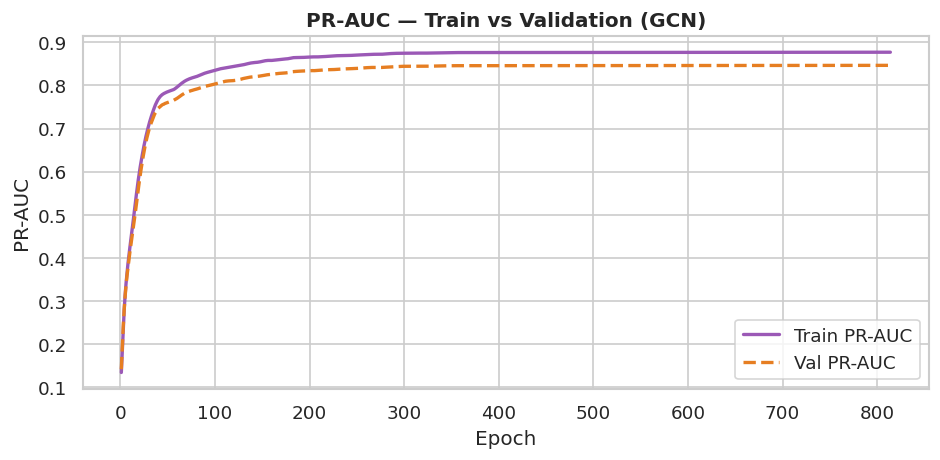

In [105]:
# ── 5-B: PR-AUC curve ──
plt.figure(figsize=(8, 4))
plt.plot(epochs_arr, history['train_pr_auc'], label='Train PR-AUC', color='#9B59B6', linewidth=2)
plt.plot(epochs_arr, history['val_pr_auc'],   label='Val PR-AUC',   color='#E67E22', linewidth=2, linestyle='--')
plt.title('PR-AUC — Train vs Validation (GCN)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('PR-AUC')
plt.legend()
plt.tight_layout()
plt.savefig('gcn_pr_auc_curve.png', bbox_inches='tight')
plt.show()

In [106]:
# ── 5-C: Final test evaluation ──
# Primary metric: default threshold = 0.50
# The calibrated val-set threshold was worse on test (concept drift means the
# val and test probability distributions differ significantly). Fixed 0.50 is fairer.
model.load_state_dict(torch.load('gcn_checkpoint.pt', map_location=DEVICE))
model.eval()
with torch.no_grad():
    logits_all = model(data_full.x.to(DEVICE), data_full.edge_index.to(DEVICE))
    test_probs = F.softmax(logits_all[test_mask.to(DEVICE)], dim=1)[:, 1].cpu().numpy()
    test_true  = data_full.y[test_mask].cpu().numpy()

# ── Primary: threshold = 0.50 ──
preds_test = (test_probs >= 0.50).astype(int)
y_test     = test_true

ts_f1   = f1_score(y_test, preds_test, zero_division=0)
ts_prec = precision_score(y_test, preds_test, zero_division=0)
ts_rec  = recall_score(y_test, preds_test, zero_division=0)
ts_pr_auc = average_precision_score(y_test, test_probs)

print('=' * 55)
print('  GCN — Test Set Results  (temporal split: ts > 34)')
print('=' * 55)
print(f'  Threshold (fixed) : 0.50')
print(f'  F1  (illicit)     : {ts_f1:.4f}')
print(f'  Precision         : {ts_prec:.4f}')
print(f'  Recall            : {ts_rec:.4f}')
print(f'  PR-AUC            : {ts_pr_auc:.4f}  ← threshold-independent')
print('=' * 55)

# ── Informational: what does the calibrated val threshold give? ──
if 'BEST_THRESH' in dir():
    preds_cal = (test_probs >= BEST_THRESH).astype(int)
    f1_cal    = f1_score(y_test, preds_cal, zero_division=0)
    print(f'\n  Note: val-calibrated thr={BEST_THRESH:.2f} → test F1={f1_cal:.4f}')
    print( '  (worse due to concept drift between val and test periods)')


  GCN — Test Set Results  (temporal split: ts > 34)
  Threshold (fixed) : 0.50
  F1  (illicit)     : 0.4559
  Precision         : 0.3729
  Recall            : 0.5863
  PR-AUC            : 0.4623  ← threshold-independent

  Note: val-calibrated thr=0.61 → test F1=0.4497
  (worse due to concept drift between val and test periods)


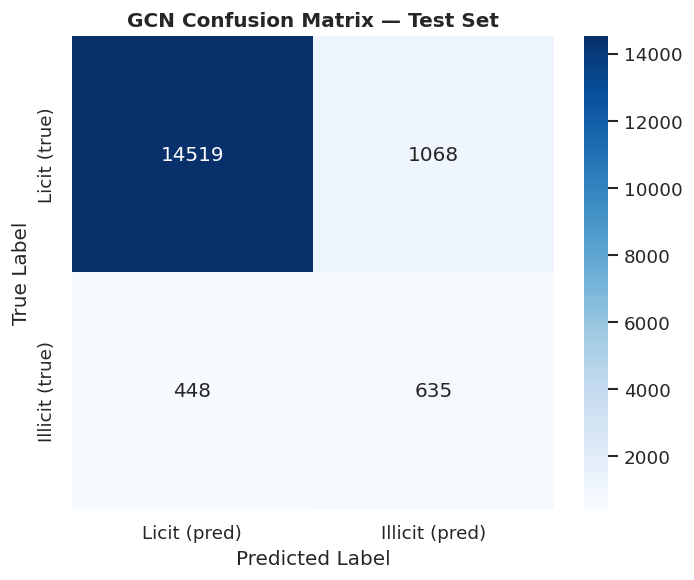


Classification Report:
              precision    recall  f1-score   support

       Licit       0.97      0.93      0.95     15587
     Illicit       0.37      0.59      0.46      1083

    accuracy                           0.91     16670
   macro avg       0.67      0.76      0.70     16670
weighted avg       0.93      0.91      0.92     16670



In [107]:
# ── 5-D: Confusion matrix ──
# preds_test and y_test are set in 5-C above (threshold=0.50)

cm = confusion_matrix(y_test, preds_test)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Licit (pred)', 'Illicit (pred)'],
    yticklabels=['Licit (true)', 'Illicit (true)'],
    ax=ax
)
ax.set_title('GCN Confusion Matrix — Test Set', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('gcn_confusion_matrix.png', bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, preds_test, target_names=['Licit', 'Illicit']))

In [108]:
# # ── 5-E: Summary table ──
# summary_df = pd.DataFrame({
#     'Metric':              ['F1 (illicit)', 'Precision', 'Recall', 'PR-AUC'],
#     'Default  (thr=0.50)': [ts_f1_def,  ts_prec_def, ts_rec_def,  None],
#     f'Calibrated (thr={BEST_THRESH:.2f})': [ts_f1_cal, ts_prec_cal, ts_rec_cal, ts_prauc],
# })
# print('\nGCN Test Results:')
# # Define the columns that contain numeric data
# numeric_cols = ['Default  (thr=0.50)', f'Calibrated (thr={BEST_THRESH:.2f})']

# # Apply formatting only to those specific columns
# display(summary_df.style.format({col: '{:.4f}' for col in numeric_cols}, na_rep='—').hide(axis='index'))

In [109]:
# Install if needed:
# !pip install torch torch_geometric scikit-learn matplotlib seaborn tqdm psutil

import os, random, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader  # needs pyg-lib or torch-sparse
from torch_geometric.nn import SAGEConv
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, classification_report, confusion_matrix
)

# ── Reproducibility ──
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


PyTorch  : 2.9.0+cu126
Device   : cuda


In [110]:
# !pip install torch-sparse -f https://data.pyg.org/whl/torch-${torch.__version__}.html
# !pip install torch-scatter -f https://data.pyg.org/whl/torch-${torch.__version__}.html
# !pip install torch-cluster -f https://data.pyg.org/whl/torch-${torch.__version__}.html
# !pip install torch-spline-conv -f https://data.pyg.org/whl/torch-${torch.__version__}.html

In [111]:
# ── Load the .pt graph objects saved by Team 1 ──
OUTPUT_DATA_DIR = "/kaggle/working/"

data_full    = torch.load(os.path.join(OUTPUT_DATA_DIR, 'elliptic_full.pt'),    map_location='cpu', weights_only=False)
data_ablated = torch.load(os.path.join(OUTPUT_DATA_DIR, 'elliptic_ablated.pt'), map_location='cpu', weights_only=False)

print('Full graph    :', data_full)
print('Ablated graph :', data_ablated)
print()
print(f'Full    — features : {data_full.num_features}  |  nodes : {data_full.num_nodes:,}  |  edges : {data_full.num_edges:,}')
print(f'Ablated — features : {data_ablated.num_features}  |  nodes : {data_ablated.num_nodes:,}  |  edges : {data_ablated.num_edges:,}')
print()
print(f'Train nodes : {data_full.train_mask.sum().item():,}')
print(f'Val   nodes : {data_full.val_mask.sum().item():,}')
print(f'Test  nodes : {data_full.test_mask.sum().item():,}')


Full graph    : Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Ablated graph : Data(x=[203769, 94], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])

Full    — features : 165  |  nodes : 203,769  |  edges : 234,355
Ablated — features : 94  |  nodes : 203,769  |  edges : 234,355

Train nodes : 23,915
Val   nodes : 5,979
Test  nodes : 16,670


In [112]:
# ── FocalLoss ──
# FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
# alpha=0.75 : illicit nodes receive 3x more gradient signal than licit ones
# gamma=2.0  : further down-weights easy, confidently-correct examples
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce      = F.cross_entropy(logits, targets, reduction='none')
        p_t     = torch.exp(-ce)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss    = alpha_t * (1 - p_t) ** self.gamma * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()

# quick sanity check
_l = FocalLoss()(torch.randn(4,2), torch.randint(0,2,(4,)))
print(f'FocalLoss test: {_l.item():.4f}  ✓')


FocalLoss test: 0.0835  ✓


In [113]:
# ── EarlyStopping ──
class EarlyStopping:
    """Track best val-F1; save checkpoint; set .stop=True after `patience` epochs without improvement."""
    def __init__(self, patience: int = 20, path: str = 'checkpoint.pt'):
        self.patience   = patience
        self.path       = path
        self.best_score = None
        self.counter    = 0
        self.stop       = False

    def __call__(self, val_f1: float, model):
        if self.best_score is None or val_f1 > self.best_score:
            self.best_score = val_f1
            self.counter    = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def train_epoch(model, data, optimizer, loss_fn, device):
    """One full-batch training pass. Returns loss on train nodes."""
    model.train()
    data_d = data.to(device)
    optimizer.zero_grad()
    out  = model(data_d.x, data_d.edge_index)
    loss = loss_fn(out[data_d.train_mask], data_d.y[data_d.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


# ── evaluate — full-graph inference ──
@torch.no_grad()
def evaluate(model, data, mask, device):
    """Return (loss, f1, precision, recall, pr_auc) on labeled nodes in `mask`."""
    model.eval()
    logits = model(data.x.to(device), data.edge_index.to(device))
    m_d    = mask.to(device)
    y_true = data.y[mask].to(device)

    loss   = FocalLoss()(logits[m_d], y_true).item()
    probs  = F.softmax(logits[m_d], dim=1)[:,1].cpu().numpy()
    preds  = (probs >= 0.5).astype(int)
    y_np   = y_true.cpu().numpy()

    f1     = f1_score(y_np, preds, zero_division=0)
    prec   = precision_score(y_np, preds, zero_division=0)
    rec    = recall_score(y_np, preds, zero_division=0)
    try:   pr_auc = average_precision_score(y_np, probs)
    except: pr_auc = 0.0
    return loss, f1, prec, rec, pr_auc

print('Shared utilities defined  ✓')


Shared utilities defined  ✓


In [114]:
# ── GraphSAGE model ──
class GraphSAGE(nn.Module):
    """GraphSAGE with Xavier classifier head (paper's best configuration)."""
    def __init__(
        self,
        in_channels: int,
        hidden_dim: int = 140,
        embedding_dim: int = 103,
        num_classes: int = 2,
        num_layers: int = 2,
        dropout: float = 0.1,
        aggregator: str = "mean",
    ) -> None:
        super().__init__()
        assert num_layers >= 1

        self.convs = nn.ModuleList()
        self.dropout = dropout

        if num_layers == 1:
            self.convs.append(SAGEConv(in_channels, embedding_dim, aggr=aggregator))
        else:
            self.convs.append(SAGEConv(in_channels, hidden_dim, aggr=aggregator))
            for _ in range(num_layers - 2):
                self.convs.append(SAGEConv(hidden_dim, hidden_dim, aggr=aggregator))
            self.convs.append(SAGEConv(hidden_dim, embedding_dim, aggr=aggregator))

        self.out = nn.Linear(embedding_dim, num_classes)
        self.reset_parameters()

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        # Xavier for classifier head
        nn.init.xavier_uniform_(self.out.weight)
        if self.out.bias is not None:
            nn.init.zeros_(self.out.bias)

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x)



model_sage = GraphSAGE(in_channels=data_full.num_features).to(DEVICE)
n_params = sum(p.numel() for p in model_sage.parameters() if p.requires_grad)
print(model_sage)
print(f'\nTrainable parameters: {n_params:,}')


GraphSAGE(
  (convs): ModuleList(
    (0): SAGEConv(165, 140, aggr=mean)
    (1): SAGEConv(140, 103, aggr=mean)
  )
  (out): Linear(in_features=103, out_features=2, bias=True)
)

Trainable parameters: 75,491


In [115]:
# ── Training — GraphSAGE full (166 features) ──
# Full-batch mode (no pyg-lib / torch-sparse required).
# On systems with pyg-lib installed, swap train_epoch to use NeighborLoader
# with num_neighbors=[10,5], batch_size=512 for true mini-batch scalability.
MAX_EPOCHS   = 5000
LR           = 1e-3
WEIGHT_DECAY = 5e-4
PATIENCE_ES  = 500
CKPT_PATH    = 'graphsage_full_checkpoint.pt'

model_sage.reset_parameters()
optimizer = torch.optim.Adam(model_sage.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = FocalLoss(alpha=0.85, gamma=2.0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10, min_lr=1e-5
)
stopper = EarlyStopping(patience=PATIENCE_ES, path=CKPT_PATH)

history = {'epoch':[], 'train_loss':[], 'val_loss':[],
           'train_f1':[], 'val_f1':[], 'val_pr_auc':[],
           'memory_mb':[], 'epoch_time_s':[]}

process = psutil.Process(os.getpid())
print(f'Training GraphSAGE (full, {data_full.num_features} features) — max {MAX_EPOCHS} ep, patience={PATIENCE_ES}')
print(f'Device: {DEVICE}\n')

for epoch in tqdm(range(1, MAX_EPOCHS+1), desc='GraphSAGE', unit='ep'):
    t0 = time.time()
    tr_loss = train_epoch(model_sage, data_full, optimizer, criterion, DEVICE)
    ep_time = time.time() - t0

    _, tr_f1, _, _, _              = evaluate(model_sage, data_full, data_full.train_mask, DEVICE)
    vl_loss, vl_f1, _, _, vl_prauc = evaluate(model_sage, data_full, data_full.val_mask,  DEVICE)

    # if torch.cuda.is_available():
    #     mem_mb = torch.cuda.memory_allocated(DEVICE) / 1024**2
    # else:
    #     mem_mb = process.memory_info().rss / 1024**2
    mem_mb=1024

    scheduler.step(vl_f1)
    current_lr = optimizer.param_groups[0]['lr']

    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)
    history['val_pr_auc'].append(vl_prauc)
    history['memory_mb'].append(mem_mb)
    history['epoch_time_s'].append(ep_time)

    if epoch % 500 == 0:
        tqdm.write(f'Ep {epoch:3d} | lr={current_lr:.2e} | '
                   f'Train F1={tr_f1:.4f} | Val F1={vl_f1:.4f}  PR-AUC={vl_prauc:.4f} | '
                   f'Mem={mem_mb:.0f} MB  t={ep_time:.1f}s')

    stopper(vl_f1, model_sage)
    if stopper.stop:
        print(f'\nEarly stopping at epoch {epoch}  (best val F1={stopper.best_score:.4f})')
        break

print(f'\nSaved: {CKPT_PATH}  (Val F1 = {stopper.best_score:.4f})')


Training GraphSAGE (full, 165 features) — max 5000 ep, patience=500
Device: cuda



GraphSAGE:  10%|█         | 501/5000 [01:07<10:08,  7.40ep/s]

Ep 500 | lr=1.00e-05 | Train F1=0.8988 | Val F1=0.8344  PR-AUC=0.9389 | Mem=1024 MB  t=0.1s


GraphSAGE:  20%|██        | 1001/5000 [02:15<08:59,  7.41ep/s]

Ep 1000 | lr=1.00e-05 | Train F1=0.9050 | Val F1=0.8388  PR-AUC=0.9406 | Mem=1024 MB  t=0.1s


...

Ep 4000 | lr=1.00e-05 | Train F1=0.9378 | Val F1=0.8625  PR-AUC=0.9496 | Mem=1024 MB  t=0.1s


GraphSAGE:  90%|█████████ | 4501/5000 [10:08<01:07,  7.38ep/s]

Ep 4500 | lr=1.00e-05 | Train F1=0.9411 | Val F1=0.8654  PR-AUC=0.9506 | Mem=1024 MB  t=0.1s


GraphSAGE: 100%|██████████| 5000/5000 [11:15<00:00,  7.40ep/s]

Ep 5000 | lr=1.00e-05 | Train F1=0.9456 | Val F1=0.8703  PR-AUC=0.9514 | Mem=1024 MB  t=0.1s

Saved: graphsage_full_checkpoint.pt  (Val F1 = 0.8703)


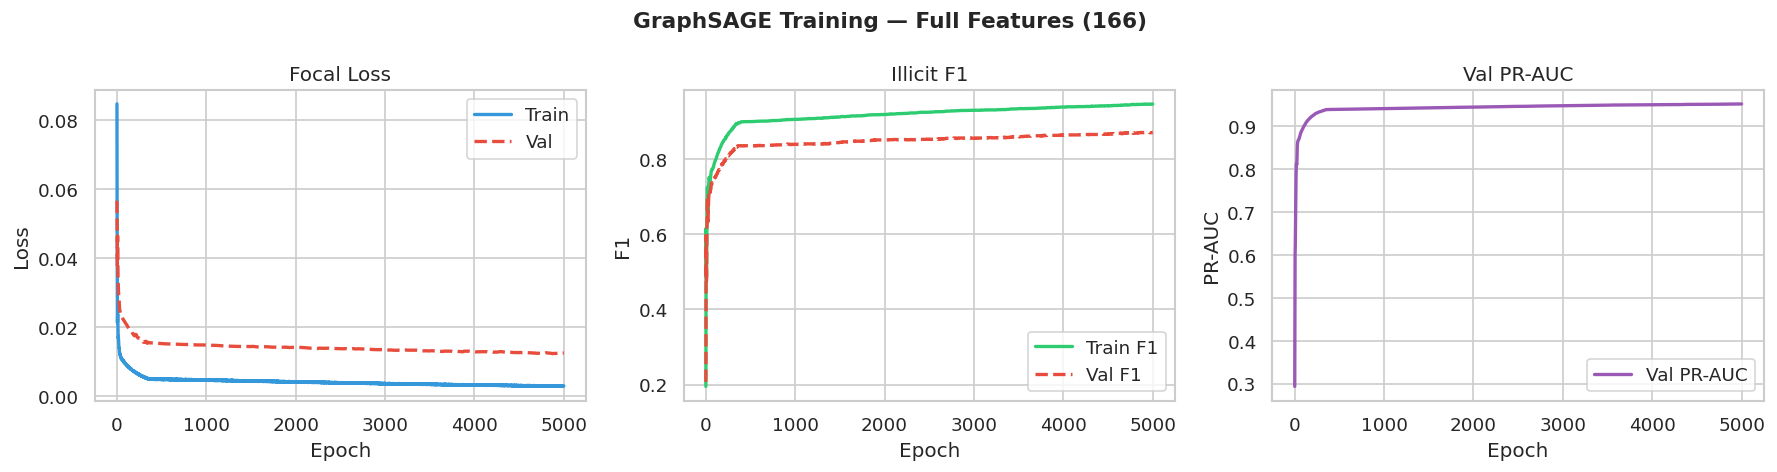

In [116]:
# ── Plot: Loss & F1 curves ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = history['epoch']

axes[0].plot(ep, history['train_loss'], label='Train', color='#3498DB', lw=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#E74C3C', lw=2, ls='--')
axes[0].set(title='Focal Loss', xlabel='Epoch', ylabel='Loss'); axes[0].legend()

axes[1].plot(ep, history['train_f1'], label='Train F1', color='#2ECC71', lw=2)
axes[1].plot(ep, history['val_f1'],   label='Val F1',   color='#E74C3C', lw=2, ls='--')
axes[1].set(title='Illicit F1', xlabel='Epoch', ylabel='F1'); axes[1].legend()

axes[2].plot(ep, history['val_pr_auc'], label='Val PR-AUC', color='#9B59B6', lw=2)
axes[2].set(title='Val PR-AUC', xlabel='Epoch', ylabel='PR-AUC'); axes[2].legend()

plt.suptitle('GraphSAGE Training — Full Features (166)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sage_training_curves.png', bbox_inches='tight')
plt.show()


---
<a id='step4'></a>
## Ablation Study

**Goal:** Prove that the 72 *aggregated structural* features (f95–f165) added by the data  
pipeline encode graph-structural information that the GNN **already learns** from the edges.  
If removing them barely hurts performance, the GNN is doing real structural learning.

| Run | Features | Source |
|-----|----------|--------|
| Full | 166 (165 financial + timestep) | `elliptic_full.pt` |
| Ablated | 95 (94 local + timestep) | `elliptic_ablated.pt` |


In [117]:
# ── Train GraphSAGE on ablated (95-feature) data ──
CKPT_ABL = 'graphsage_ablated_checkpoint.pt'

model_abl = GraphSAGE(in_channels=data_ablated.num_features).to(DEVICE)
model_abl.reset_parameters()

opt_abl  = torch.optim.Adam(model_abl.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sch_abl  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_abl, mode='max', factor=0.5, patience=10, min_lr=1e-5)
stop_abl = EarlyStopping(patience=PATIENCE_ES, path=CKPT_ABL)

hist_abl = {'epoch':[],'val_f1':[],'val_pr_auc':[]}

print(f'Training GraphSAGE (ablated, {data_ablated.num_features} features)...\n')

for epoch in tqdm(range(1, MAX_EPOCHS+1), desc='Ablated SAGE', unit='ep'):
    train_epoch(model_abl, data_ablated, opt_abl, criterion, DEVICE)
    _, vl_f1, _, _, vl_prauc = evaluate(model_abl, data_ablated, data_ablated.val_mask, DEVICE)
    sch_abl.step(vl_f1)
    hist_abl['epoch'].append(epoch)
    hist_abl['val_f1'].append(vl_f1)
    hist_abl['val_pr_auc'].append(vl_prauc)
    stop_abl(vl_f1, model_abl)
    if stop_abl.stop:
        print(f'Early stopping at epoch {epoch}  (best val F1={stop_abl.best_score:.4f})')
        break

print(f'\nSaved: {CKPT_ABL}  (Val F1 = {stop_abl.best_score:.4f})')


Training GraphSAGE (ablated, 94 features)...



Ablated SAGE: 100%|██████████| 5000/5000 [06:34<00:00, 12.67ep/s]


Saved: graphsage_ablated_checkpoint.pt  (Val F1 = 0.7893)


In [118]:
# ── Test evaluation: full vs ablated ──
model_sage.load_state_dict(torch.load(CKPT_PATH,    map_location=DEVICE, weights_only=False))
model_abl.load_state_dict( torch.load(CKPT_ABL,     map_location=DEVICE, weights_only=False))

_, f1_full, prec_full, rec_full, prauc_full = evaluate(
    model_sage, data_full,    data_full.test_mask,    DEVICE)
_, f1_abl,  prec_abl,  rec_abl,  prauc_abl  = evaluate(
    model_abl,  data_ablated, data_ablated.test_mask, DEVICE)

ablation_df = pd.DataFrame({
    'Variant'         : ['Full (166 feat)', 'Ablated (95 feat)', 'Δ (Full − Ablated)'],
    'F1 (illicit)'    : [f1_full,    f1_abl,    f1_full  - f1_abl],
    'Precision'       : [prec_full,  prec_abl,  prec_full - prec_abl],
    'Recall'          : [rec_full,   rec_abl,   rec_full  - rec_abl],
    'PR-AUC'          : [prauc_full, prauc_abl, prauc_full - prauc_abl],
})
print('\n=== Ablation Study — Test Set Results ===')
display(ablation_df.style.format({c:'{:.4f}' for c in ablation_df.columns[1:]}).hide(axis='index'))
print()
print('Interpretation:')
print('  • Small Δ F1 → GNN learns structural patterns from edges, not pre-computed features.')
print('  • Large Δ F1 → Aggregated structural features carry additional non-graph signal.')



=== Ablation Study — Test Set Results ===


Variant,F1 (illicit),Precision,Recall,PR-AUC
Full (166 feat),0.5830,0.5360,0.6390,0.6035
Ablated (95 feat),0.5027,0.3827,0.7322,0.7003
Δ (Full − Ablated),0.0803,0.1533,-0.0933,-0.0968



Interpretation:
  • Small Δ F1 → GNN learns structural patterns from edges, not pre-computed features.
  • Large Δ F1 → Aggregated structural features carry additional non-graph signal.


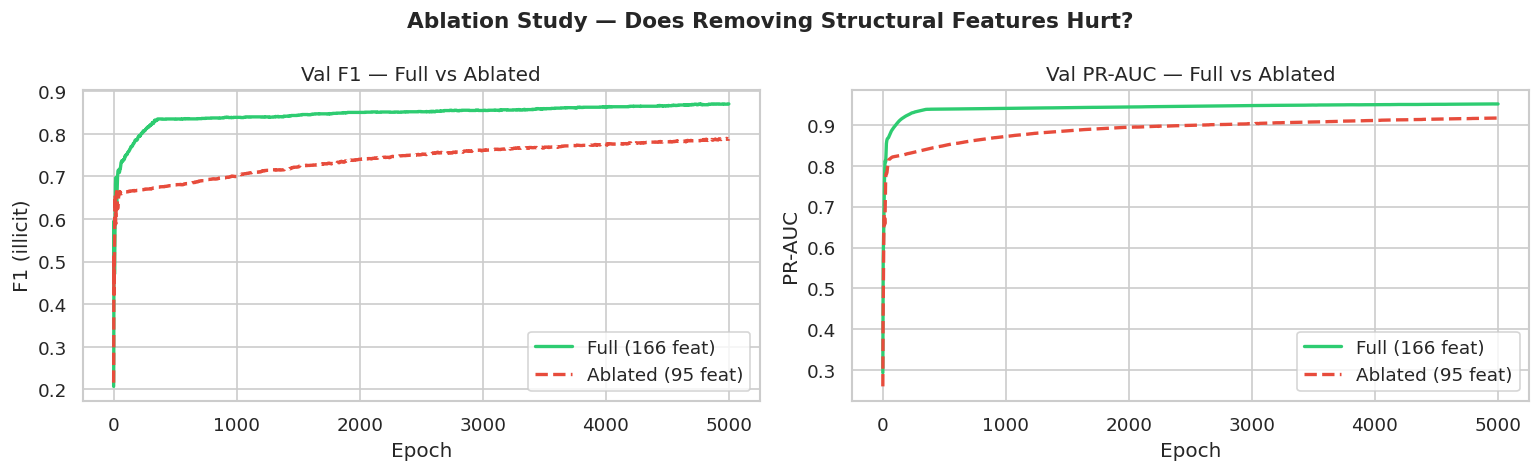

In [119]:
# ── Plot ablation: val F1 curves side by side ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ep_f   = history['epoch']
ep_a   = hist_abl['epoch']

axes[0].plot(ep_f, history['val_f1'],       lw=2, color='#2ECC71',  label='Full (166 feat)')
axes[0].plot(ep_a, hist_abl['val_f1'],      lw=2, color='#E74C3C',  label='Ablated (95 feat)', ls='--')
axes[0].set(title='Val F1 — Full vs Ablated', xlabel='Epoch', ylabel='F1 (illicit)')
axes[0].legend()

axes[1].plot(ep_f, history['val_pr_auc'],   lw=2, color='#2ECC71',  label='Full (166 feat)')
axes[1].plot(ep_a, hist_abl['val_pr_auc'],  lw=2, color='#E74C3C',  label='Ablated (95 feat)', ls='--')
axes[1].set(title='Val PR-AUC — Full vs Ablated', xlabel='Epoch', ylabel='PR-AUC')
axes[1].legend()

plt.suptitle('Ablation Study — Does Removing Structural Features Hurt?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sage_ablation.png', bbox_inches='tight')
plt.show()


---
<a id='step5'></a>
## Hyperparameter Sensitivity

Vary **learning rate** and **hidden dimension** to find the best configuration.  
All other settings fixed: FocalLoss (α=0.75, γ=2), patience=20, max 200 epochs.


In [120]:
# ── Hyperparameter grid search ──
HP_GRID = [
    {'lr': 1e-3, 'hidden': 128},
    {'lr': 1e-3, 'hidden':  64},
    {'lr': 5e-4, 'hidden': 128},
    {'lr': 5e-4, 'hidden':  64},
]
HP_MAX_EP = 150   # shorter for sweep speed

hp_results = []
print('Running hyperparameter sensitivity sweep...\n')
_loader = data_full

for cfg in HP_GRID:
    _model = GraphSAGE(in_channels=data_full.num_features,
                       hidden_dim=cfg['hidden']).to(DEVICE)
    _model.reset_parameters()
    _opt   = torch.optim.Adam(_model.parameters(), lr=cfg['lr'], weight_decay=WEIGHT_DECAY)
    _stop  = EarlyStopping(patience=15, path=f'hp_lr{cfg["lr"]}_h{cfg["hidden"]}.pt')
    _crit  = FocalLoss(alpha=0.85, gamma=2.0)

    best_val_f1 = 0.0
    for ep in range(1, HP_MAX_EP+1):
        train_epoch(_model, _loader, _opt, _crit, DEVICE)
        _, vl_f1, _, _, vl_prauc = evaluate(_model, data_full, data_full.val_mask, DEVICE)
        _stop(vl_f1, _model)
        if _stop.stop: break

    _model.load_state_dict(torch.load(f'hp_lr{cfg["lr"]}_h{cfg["hidden"]}.pt', map_location=DEVICE, weights_only=False))
    _, ts_f1, ts_prec, ts_rec, ts_prauc = evaluate(_model, data_full, data_full.test_mask, DEVICE)

    hp_results.append({
        'LR': cfg['lr'], 'Hidden dim': cfg['hidden'],
        'Best Val F1': _stop.best_score,
        'Test F1':     ts_f1,
        'Test PR-AUC': ts_prauc,
        'Stopped at':  ep,
    })
    print(f"  lr={cfg['lr']}  hidden={cfg['hidden']:3d} → Val F1={_stop.best_score:.4f}  Test F1={ts_f1:.4f}  PR-AUC={ts_prauc:.4f}")

hp_df = pd.DataFrame(hp_results)
print('\nHyperparameter Sensitivity Results:')
display(hp_df.style.format({
    'LR':'{:.0e}','Best Val F1':'{:.4f}','Test F1':'{:.4f}','Test PR-AUC':'{:.4f}'
}).highlight_max(subset=['Test F1','Test PR-AUC'], color='#d4f7d4').hide(axis='index'))

best_row = hp_df.loc[hp_df['Test F1'].idxmax()]
print(f'\nBest config: lr={best_row["LR"]:.0e}  hidden={int(best_row["Hidden dim"])}  → Test F1={best_row["Test F1"]:.4f}')


Running hyperparameter sensitivity sweep...

  lr=0.001  hidden=128 → Val F1=0.8370  Test F1=0.5368  PR-AUC=0.6480
  lr=0.001  hidden= 64 → Val F1=0.8290  Test F1=0.5092  PR-AUC=0.6243
  lr=0.0005  hidden=128 → Val F1=0.7818  Test F1=0.4365  PR-AUC=0.6516
  lr=0.0005  hidden= 64 → Val F1=0.7980  Test F1=0.4275  PR-AUC=0.6184

Hyperparameter Sensitivity Results:


LR,Hidden dim,Best Val F1,Test F1,Test PR-AUC,Stopped at
1e-03,128,0.8370,0.5368,0.6480,150
1e-03,64,0.8290,0.5092,0.6243,150
5e-04,128,0.7818,0.4365,0.6516,150
5e-04,64,0.7980,0.4275,0.6184,150



Best config: lr=1e-03  hidden=128  → Test F1=0.5368


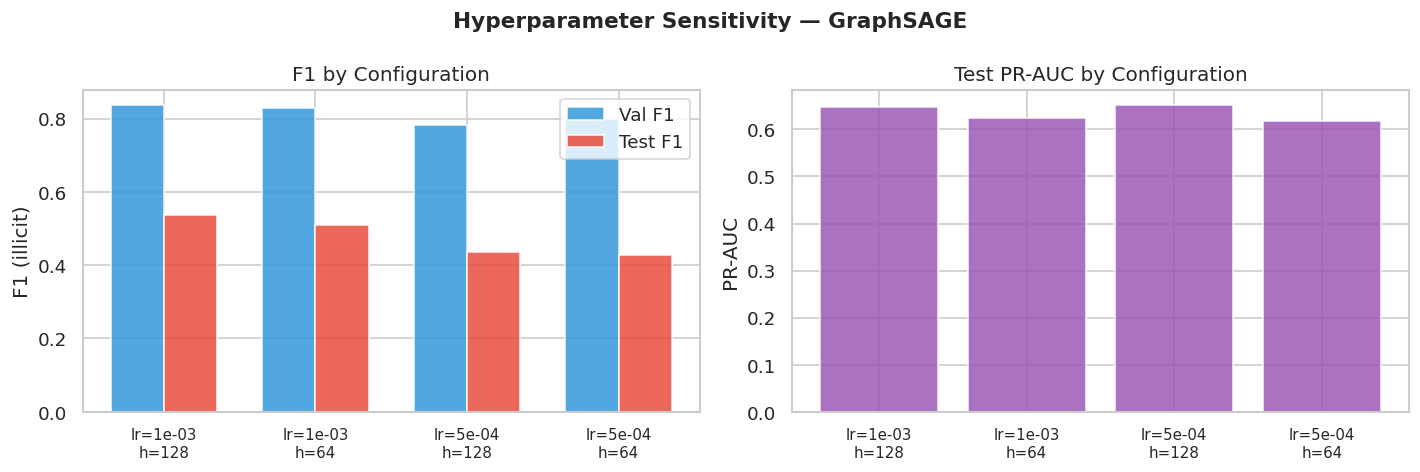

In [121]:
# ── Plot HP sensitivity ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

labels = [f'lr={r["LR"]:.0e}\nh={int(r["Hidden dim"])}' for _, r in hp_df.iterrows()]
x      = np.arange(len(labels))
w      = 0.35

ax1.bar(x - w/2, hp_df['Best Val F1'], w, label='Val F1',  color='#3498DB', alpha=0.85)
ax1.bar(x + w/2, hp_df['Test F1'],     w, label='Test F1', color='#E74C3C', alpha=0.85)
ax1.set(title='F1 by Configuration', ylabel='F1 (illicit)')
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=9); ax1.legend()

ax2.bar(x, hp_df['Test PR-AUC'], color='#9B59B6', alpha=0.85)
ax2.set(title='Test PR-AUC by Configuration', ylabel='PR-AUC')
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=9)

plt.suptitle('Hyperparameter Sensitivity — GraphSAGE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sage_hp_sensitivity.png', bbox_inches='tight')
plt.show()


---
<a id='step6'></a>
## Final Results


In [122]:
# ── Final test evaluation with best checkpoint ──
model_sage.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False))

with torch.no_grad():
    logits_all = model_sage(data_full.x.to(DEVICE), data_full.edge_index.to(DEVICE))
    test_probs = F.softmax(logits_all[data_full.test_mask.to(DEVICE)], dim=1)[:,1].cpu().numpy()
    test_true  = data_full.y[data_full.test_mask].cpu().numpy()

preds_test = (test_probs >= 0.5).astype(int)

ts_f1   = f1_score(test_true, preds_test, zero_division=0)
ts_prec = precision_score(test_true, preds_test, zero_division=0)
ts_rec  = recall_score(test_true, preds_test, zero_division=0)
ts_prauc = average_precision_score(test_true, test_probs)

print('=' * 55)
print('  GraphSAGE — Test Set (temporal split: ts > 34)')
print('=' * 55)
print(f'  F1  (illicit) : {ts_f1:.4f}')
print(f'  Precision     : {ts_prec:.4f}')
print(f'  Recall        : {ts_rec:.4f}')
print(f'  PR-AUC        : {ts_prauc:.4f}')
print('=' * 55)

# Classification report
print()
print(classification_report(test_true, preds_test, target_names=['Licit','Illicit']))


  GraphSAGE — Test Set (temporal split: ts > 34)
  F1  (illicit) : 0.5830
  Precision     : 0.5360
  Recall        : 0.6390
  PR-AUC        : 0.6035

              precision    recall  f1-score   support

       Licit       0.97      0.96      0.97     15587
     Illicit       0.54      0.64      0.58      1083

    accuracy                           0.94     16670
   macro avg       0.76      0.80      0.78     16670
weighted avg       0.95      0.94      0.94     16670



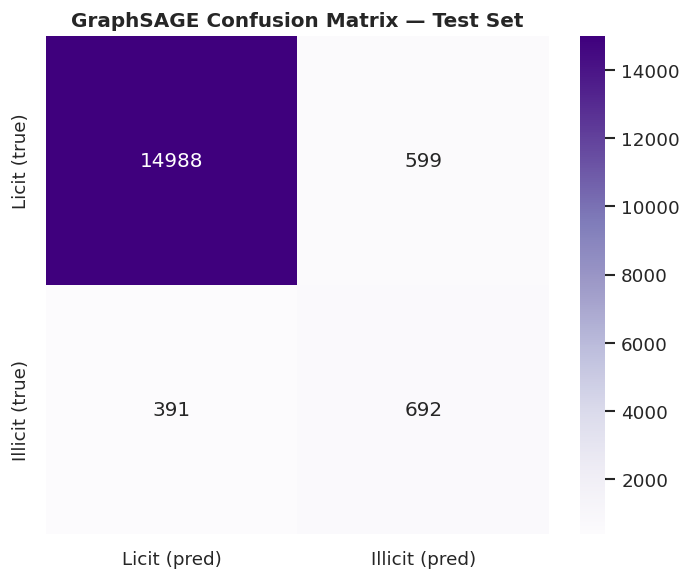

In [123]:
# ── Confusion matrix ──
cm = confusion_matrix(test_true, preds_test)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Licit (pred)','Illicit (pred)'],
            yticklabels=['Licit (true)','Illicit (true)'], ax=ax)
ax.set_title('GraphSAGE Confusion Matrix — Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sage_confusion_matrix.png', bbox_inches='tight')
plt.show()


In [124]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GraphNorm
from torch_geometric.utils import to_networkx, k_hop_subgraph
import matplotlib.patches as mpatches
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


PyTorch  : 2.9.0+cu126
Device   : cuda


In [125]:
# ── Load graph (Team 1 output) ──
DATA_DIR = '/kaggle/working/'

data_full = torch.load(os.path.join(DATA_DIR, 'elliptic_full.pt'),
                       map_location='cpu', weights_only=False)
print('Graph loaded:', data_full)
print(f'  Nodes     : {data_full.num_nodes:,}')
print(f'  Edges     : {data_full.num_edges:,}')
print(f'  Features  : {data_full.num_features}')
print(f'  Train     : {data_full.train_mask.sum().item():,}')
print(f'  Val       : {data_full.val_mask.sum().item():,}')
print(f'  Test      : {data_full.test_mask.sum().item():,}')


Graph loaded: Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
  Nodes     : 203,769
  Edges     : 234,355
  Features  : 165
  Train     : 23,915
  Val       : 5,979
  Test      : 16,670


In [126]:
# ── Shared utilities (copied from Team 2 for standalone execution) ──
class FocalLoss(nn.Module):
    """FL(p_t) = -alpha_t * (1-p_t)^gamma * log(p_t). alpha=0.75 favours illicit minority."""
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.reduction = reduction
    def forward(self, logits, targets):
        ce      = F.cross_entropy(logits, targets, reduction='none')
        p_t     = torch.exp(-ce)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss    = alpha_t * (1 - p_t) ** self.gamma * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()

class EarlyStopping:
    def __init__(self, patience=20, path='checkpoint.pt'):
        self.patience=patience; self.path=path
        self.best_score=None; self.counter=0; self.stop=False
    def __call__(self, val_f1, model):
        if self.best_score is None or val_f1 > self.best_score:
            self.best_score=val_f1; self.counter=0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience: self.stop = True

@torch.no_grad()
def evaluate(model, data, mask, device):
    model.eval()
    logits = model(data.x.to(device), data.edge_index.to(device))
    m_d    = mask.to(device)
    y_true = data.y[mask].to(device)
    loss   = FocalLoss()(logits[m_d], y_true).item()
    probs  = F.softmax(logits[m_d], dim=1)[:,1].cpu().numpy()
    preds  = (probs >= 0.5).astype(int)
    y_np   = y_true.cpu().numpy()
    f1     = f1_score(y_np, preds, zero_division=0)
    prec   = precision_score(y_np, preds, zero_division=0)
    rec    = recall_score(y_np, preds, zero_division=0)
    try:   pr_auc = average_precision_score(y_np, probs)
    except: pr_auc = 0.0
    return loss, f1, prec, rec, pr_auc

print('Shared utilities ready  ✓')


Shared utilities ready  ✓


---
<a id='step2'></a>
## GAT Model Definition & Training




### Why GAT addresses explainability
GAT learns a **separate attention weight α_{ij}** for each edge (i→j).  
These weights tell us *how much node i relies on neighbor j* when forming its representation.  
For illicit transactions, high-attention edges point to the most suspicious connections —  
giving compliance teams interpretable evidence.

**Training:** FocalLoss (α=0.75, γ=2) · Adam (lr=0.001) · ReduceLROnPlateau · EarlyStopping (patience=20)


In [127]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super(GAT, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False)
        # Placeholders for attention weights
        self.attn1 = None
        self.attn2 = None

    def reset_parameters(self):
        self.conv1.reset_parameters()
        self.conv2.reset_parameters()

    def forward(self, x, edge_index, return_attention=False):
        if return_attention:
            # Get attention weights for the first layer
            x, (ei1, w1) = self.conv1(x, edge_index, return_attention_weights=True)
            self.attn1 = (ei1, w1)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)
            
            # Get attention weights for the second layer
            x, (ei2, w2) = self.conv2(x, edge_index, return_attention_weights=True)
            self.attn2 = (ei2, w2)
        else:
            x = self.conv1(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)
            x = self.conv2(x, edge_index)
            
        return F.log_softmax(x, dim=1)



model_gat = GAT(
    in_channels=data_full.num_features, 
    hidden_channels=64, 
    out_channels=2,
    heads=4
).to(DEVICE)


n_params = sum(p.numel() for p in model_gat.parameters() if p.requires_grad)
print(model_gat)
print(f"\nTrainable parameters: {n_params:,}")


GAT(
  (conv1): GATConv(165, 64, heads=4)
  (conv2): GATConv(256, 2, heads=1)
)

Trainable parameters: 43,526


In [128]:
# ── Training ──
MAX_EPOCHS   = 5000
LR           = 1e-3
WEIGHT_DECAY = 1e-3   # stronger regularisation to stop attention collapse
PATIENCE_ES  = 500
CKPT_PATH    = 'gat_checkpoint.pt'

model_gat.reset_parameters()
optimiser = torch.optim.Adam(model_gat.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = FocalLoss(alpha=0.85, gamma=2.0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='max', factor=0.5, patience=15, min_lr=1e-5)
stopper   = EarlyStopping(patience=PATIENCE_ES, path=CKPT_PATH)

data_d = data_full.to(DEVICE)
history = {'epoch':[],'train_loss':[],'val_loss':[],'train_f1':[],'val_f1':[],'val_pr_auc':[]}

print(f'Training GAT — max {MAX_EPOCHS} ep, patience={PATIENCE_ES}')
print(f'Device: {DEVICE}\n')

for epoch in tqdm(range(1, MAX_EPOCHS+1), desc='GAT', unit='ep'):
    model_gat.train()
    optimiser.zero_grad()
    logits = model_gat(data_d.x, data_d.edge_index)
    loss   = criterion(logits[data_d.train_mask], data_d.y[data_d.train_mask])
    loss.backward(); optimiser.step()

    tr_loss, tr_f1, _, _, _             = evaluate(model_gat, data_full, data_full.train_mask, DEVICE)
    vl_loss, vl_f1, _, _, vl_prauc      = evaluate(model_gat, data_full, data_full.val_mask,   DEVICE)

    scheduler.step(vl_f1)
    lr_now = optimiser.param_groups[0]['lr']

    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1);    history['val_f1'].append(vl_f1)
    history['val_pr_auc'].append(vl_prauc)

    if epoch % 500 == 0:
        tqdm.write(f'Ep {epoch:3d} | lr={lr_now:.2e} | '
                   f'Train F1={tr_f1:.4f} | Val F1={vl_f1:.4f}  PR-AUC={vl_prauc:.4f}')
    stopper(vl_f1, model_gat)
    if stopper.stop:
        print(f'\nEarly stopping at epoch {epoch}  (best val F1={stopper.best_score:.4f})')
        break

print(f'\nSaved: {CKPT_PATH}  (Val F1 = {stopper.best_score:.4f})')


Training GAT — max 5000 ep, patience=500
Device: cuda



GAT:  10%|█         | 501/5000 [01:27<13:11,  5.69ep/s]

Ep 500 | lr=1.00e-05 | Train F1=0.7884 | Val F1=0.7578  PR-AUC=0.8891


GAT:  20%|██        | 1001/5000 [02:54<11:41,  5.70ep/s]

Ep 1000 | lr=1.00e-05 | Train F1=0.7892 | Val F1=0.7596  PR-AUC=0.8883


...

Ep 2000 | lr=1.00e-05 | Train F1=0.7927 | Val F1=0.7634  PR-AUC=0.8906


GAT:  50%|█████     | 2501/5000 [07:17<07:19,  5.68ep/s]

Ep 2500 | lr=1.00e-05 | Train F1=0.7939 | Val F1=0.7649  PR-AUC=0.8918


GAT:  56%|█████▌    | 2806/5000 [08:10<06:23,  5.72ep/s]


Early stopping at epoch 2807  (best val F1=0.7663)

Saved: gat_checkpoint.pt  (Val F1 = 0.7663)


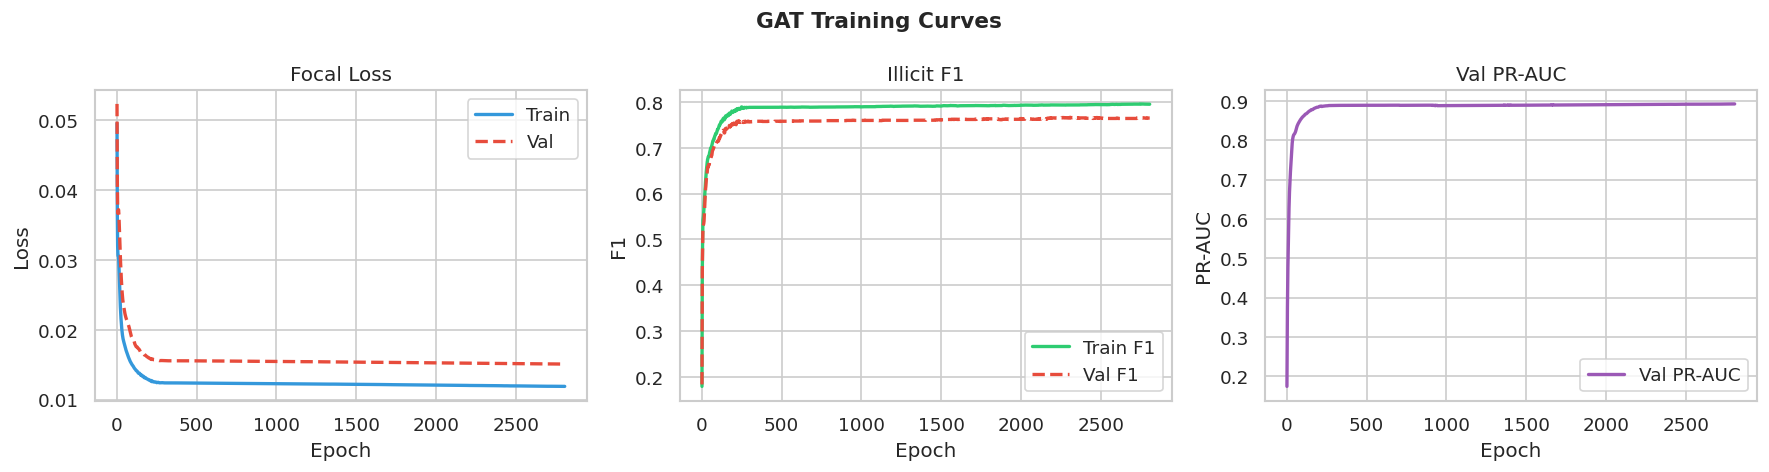

In [129]:
# ── Training curves ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = history['epoch']

axes[0].plot(ep, history['train_loss'], lw=2, color='#3498DB', label='Train')
axes[0].plot(ep, history['val_loss'],   lw=2, color='#E74C3C', label='Val', ls='--')
axes[0].set(title='Focal Loss', xlabel='Epoch', ylabel='Loss'); axes[0].legend()

axes[1].plot(ep, history['train_f1'], lw=2, color='#2ECC71', label='Train F1')
axes[1].plot(ep, history['val_f1'],   lw=2, color='#E74C3C', label='Val F1',  ls='--')
axes[1].set(title='Illicit F1', xlabel='Epoch', ylabel='F1'); axes[1].legend()

axes[2].plot(ep, history['val_pr_auc'], lw=2, color='#9B59B6', label='Val PR-AUC')
axes[2].set(title='Val PR-AUC', xlabel='Epoch', ylabel='PR-AUC'); axes[2].legend()

plt.suptitle('GAT Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gat_training_curves.png', bbox_inches='tight')
plt.show()


### Threshold Calibration

A fixed 0.5 threshold can hurt F1 on imbalanced test sets. We sweep thresholds
on the **validation set** and pick the one maximising illicit F1.


Best threshold (val F1 = 0.8259) : 0.59


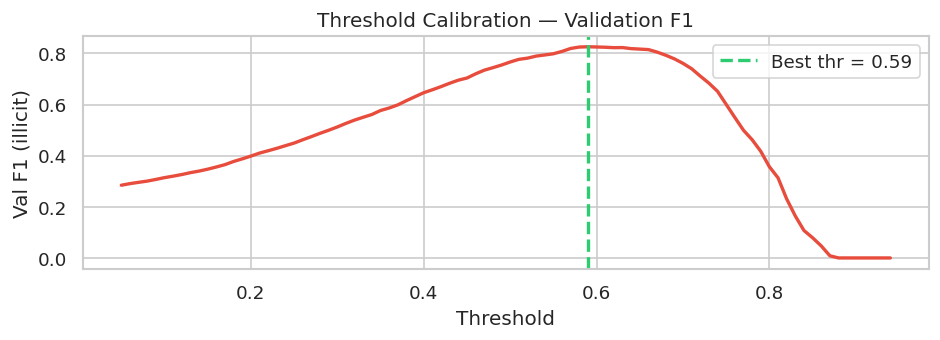

In [130]:
# ── Threshold calibration on val set ──
model_gat.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False))
model_gat.eval()

with torch.no_grad():
    logits_val = model_gat(data_full.x.to(DEVICE), data_full.edge_index.to(DEVICE))
    val_probs  = F.softmax(logits_val[data_full.val_mask.to(DEVICE)], dim=1)[:,1].cpu().numpy()
    val_true   = data_full.y[data_full.val_mask].cpu().numpy()

thresholds = np.arange(0.05, 0.95, 0.01)
val_f1s    = [f1_score(val_true, (val_probs >= t).astype(int), zero_division=0)
              for t in thresholds]

BEST_THRESH = float(thresholds[np.argmax(val_f1s)])
print(f'Best threshold (val F1 = {max(val_f1s):.4f}) : {BEST_THRESH:.2f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(thresholds, val_f1s, color='#E74C3C', lw=2)
ax.axvline(BEST_THRESH, color='#2ECC71', ls='--', lw=2,
           label=f'Best thr = {BEST_THRESH:.2f}')
ax.set(title='Threshold Calibration — Validation F1', xlabel='Threshold', ylabel='Val F1 (illicit)')
ax.legend(); plt.tight_layout()
plt.savefig('gat_threshold_calibration.png', bbox_inches='tight')
plt.show()


---
<a id='step3'></a>
## Attention Weight Visualisation

GAT learns edge-level attention weights α_{ij} ∈ (0,1) indicating how much  
node *i* attends to neighbor *j*. High-weight edges on an illicit node reveal  
which *connections* the model considers most suspicious.



In [131]:
# ── Compute attention weights on the full graph ──
model_gat.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False))
model_gat.eval()

with torch.no_grad():
    _ = model_gat(data_full.x.to(DEVICE), data_full.edge_index.to(DEVICE),
                  return_attention=True)
    # attn2: (edge_index [2,E], weights [E,1])
    ei2, attn_weights = model_gat.attn2
    attn_scores = attn_weights.squeeze(-1).cpu().numpy()   # shape (E,)

# Get predicted-illicit nodes on test set
with torch.no_grad():
    logits_all = model_gat(data_full.x.to(DEVICE), data_full.edge_index.to(DEVICE))
    test_probs = F.softmax(logits_all[data_full.test_mask.to(DEVICE)], dim=1)[:,1].cpu().numpy()
    test_preds = (test_probs >= 0.5).astype(int)
    test_true  = data_full.y[data_full.test_mask].cpu().numpy()

test_node_ids = data_full.test_mask.nonzero(as_tuple=True)[0]
pred_illicit_mask = (test_preds == 1)
pred_illicit_nodes = test_node_ids[pred_illicit_mask]

print(f'Predicted illicit on test set: {len(pred_illicit_nodes):,}')
print(f'True illicit in test set     : {(test_true==1).sum():,}')


Predicted illicit on test set: 1,906
True illicit in test set     : 1,083


---
<a id='step4'></a>
## GNNExplainer (Explainability Mitigation)

**Explainability challenge addressed here:**  
GNNExplainer learns a soft mask over the edges and node features  
of a target node's computation graph that *maximally preserves* the model's prediction.  
Output: the most influential subgraph edges and top node features for each prediction.

We run GNNExplainer on 3–5 true-positive illicit predictions and interpret the results.


In [132]:
from torch_geometric.explain import Explainer, GNNExplainer

# ── Configure GNNExplainer ──
explainer = Explainer(
    model=model_gat,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='raw',
    ),
)
print('GNNExplainer configured  ✓')
print('Will explain 3 true-positive illicit predictions.')


GNNExplainer configured  ✓
Will explain 3 true-positive illicit predictions.


In [133]:
# ── Run GNNExplainer on 3 true-positive nodes ──
# Use a manageable subset of the graph for speed
N_EXPLAIN = 3
explain_nodes = tp_nodes[:N_EXPLAIN].tolist()

explanations = []
for node_idx in explain_nodes:
    print(f'Explaining node {node_idx} ...', end=' ')
    exp = explainer(
        x          = data_full.x.to(DEVICE),
        edge_index = data_full.edge_index.to(DEVICE),
        index      = node_idx,
    )
    explanations.append(exp)
    print(f'done  (prediction={exp.prediction.argmax().item()})')

print(f'\n{N_EXPLAIN} explanations computed.')


Explaining node 136279 ... done  (prediction=32)
Explaining node 136280 ... done  (prediction=32)
Explaining node 136371 ... done  (prediction=32)

3 explanations computed.


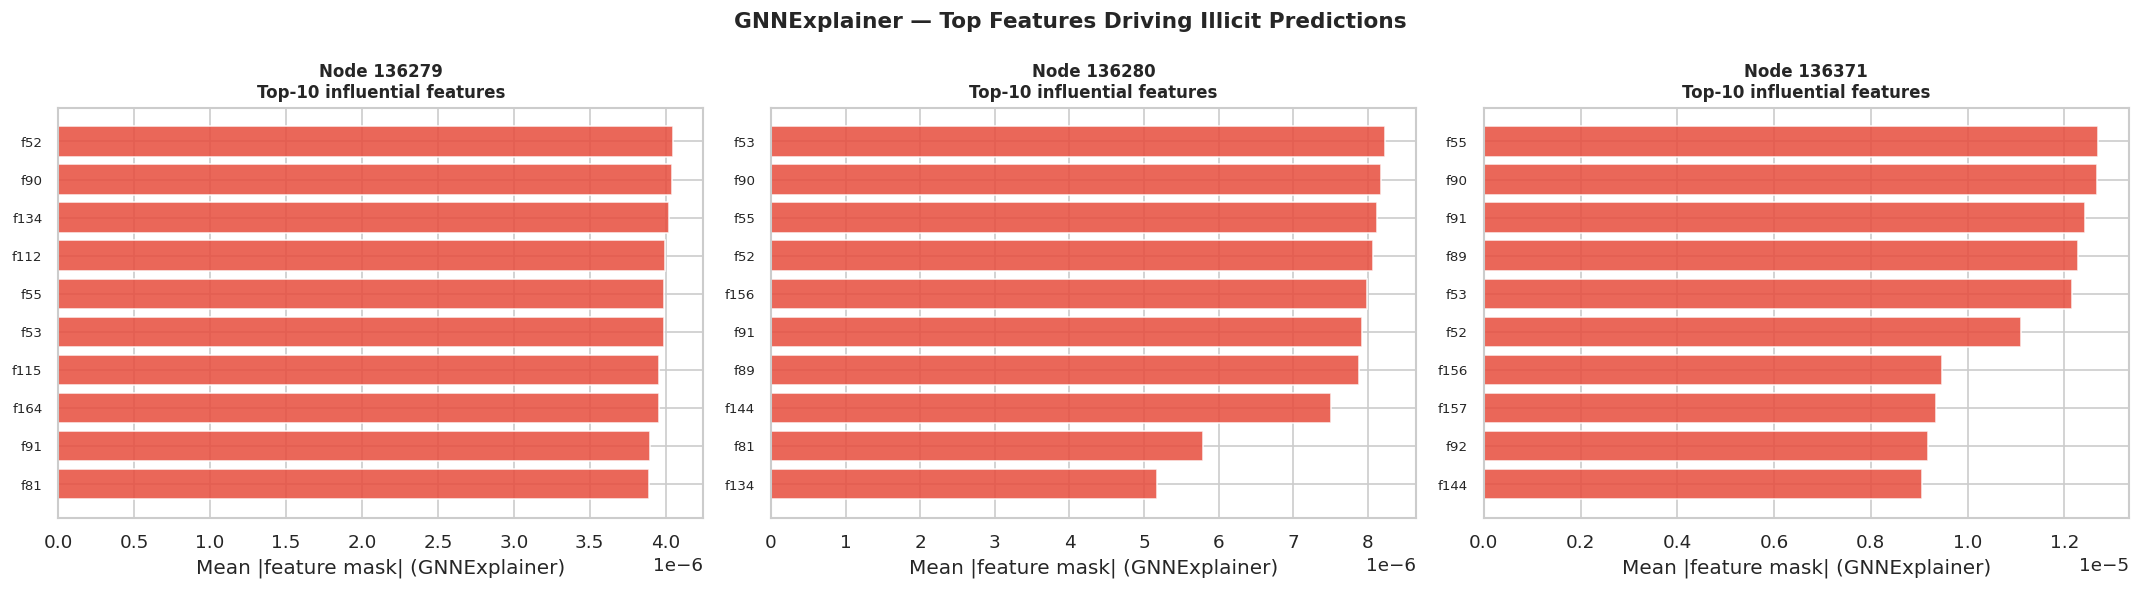

In [134]:
# ── Visualise GNNExplainer output for each node ──
FEAT_NAMES = [f'f{i}' for i in range(1, 166)] + ['timestep']

fig, axes = plt.subplots(1, N_EXPLAIN, figsize=(6 * N_EXPLAIN, 5))
if N_EXPLAIN == 1: axes = [axes]

for ax, exp, node_idx in zip(axes, explanations, explain_nodes):
    node_mask = exp.node_mask   # shape (num_nodes_in_explanation, num_features)

    if node_mask is not None and node_mask.numel() > 0:
        # Average absolute feature importance across all explanation nodes
        feat_imp = node_mask.abs().mean(dim=0).cpu().detach()  # shape (F,)

        top_k    = min(10, feat_imp.shape[0])
        top_vals, top_idx = feat_imp.topk(top_k)
        top_vals  = top_vals.numpy()
        top_names = [FEAT_NAMES[i] if i < len(FEAT_NAMES) else f'feat_{i}'
                     for i in top_idx.numpy()]

        ax.barh(range(top_k), top_vals[::-1], color='#E74C3C', alpha=0.85)
        ax.set_yticks(range(top_k))
        ax.set_yticklabels(top_names[::-1], fontsize=8)
        ax.set_xlim(left=0)
        ax.set_title(f'Node {node_idx}\nTop-{top_k} influential features',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Mean |feature mask| (GNNExplainer)')
    else:
        ax.text(0.5, 0.5, 'No node mask', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(f'Node {node_idx}')

plt.suptitle('GNNExplainer — Top Features Driving Illicit Predictions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gnnexplainer_feature_importance.png', bbox_inches='tight')
plt.show()


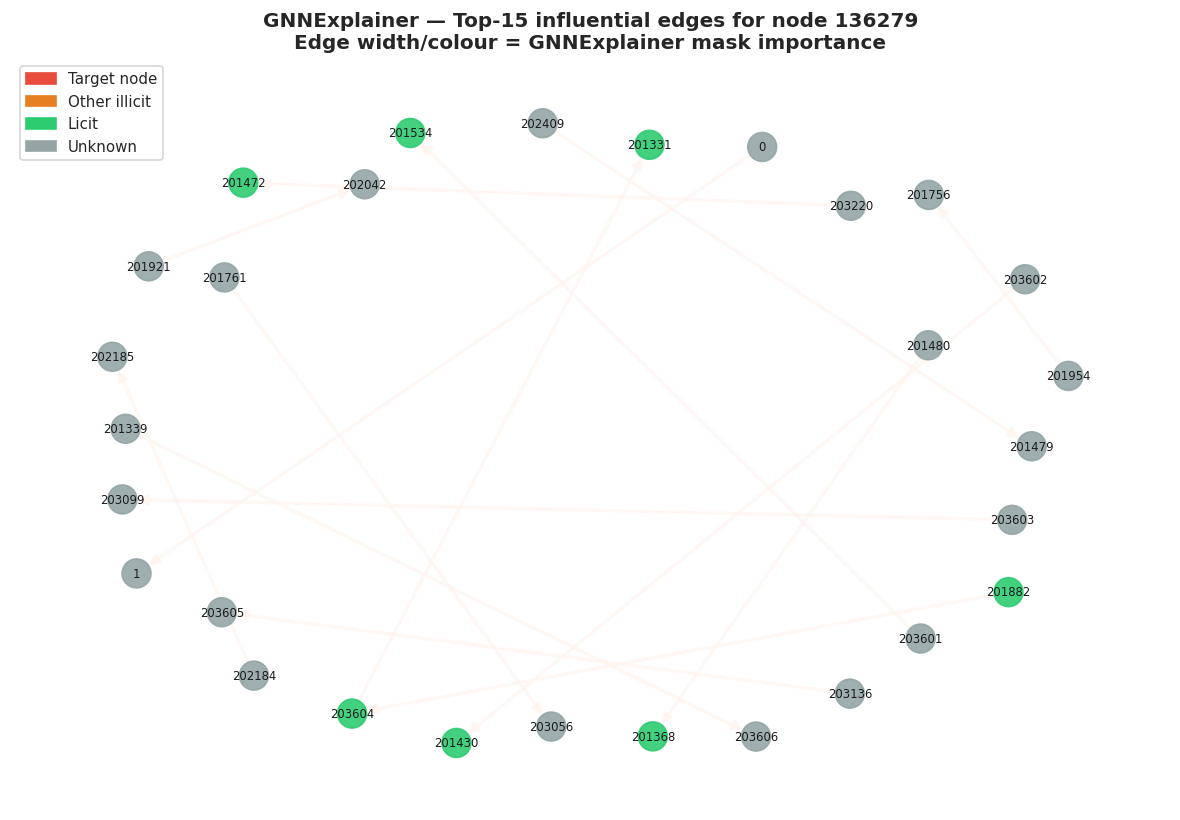

Interpretation: thick red edges are the connections GNNExplainer
identifies as most responsible for the illicit prediction.


In [135]:
# ── Visualise the explanatory subgraph for the first node ──
exp   = explanations[0]
nidx  = explain_nodes[0]

edge_mask_vals = exp.edge_mask.cpu().numpy()        # importance per edge
ei_exp         = exp.edge_index.cpu().numpy()       # (2, E)

# Keep top-15 edges by importance
TOP_EDGES = min(15, len(edge_mask_vals))
top_edge_idx = np.argsort(edge_mask_vals)[-TOP_EDGES:]

G_exp = nx.DiGraph()
for idx in top_edge_idx:
    u, v = int(ei_exp[0, idx]), int(ei_exp[1, idx])
    G_exp.add_edge(u, v, weight=float(edge_mask_vals[idx]))

node_list   = list(G_exp.nodes())
node_col    = ['#E74C3C' if n == nidx else
               ('#E67E22' if n in tp_nodes.tolist() else
                ('#2ECC71' if n < len(y_arr) and y_arr[n] == 0 else '#95A5A6'))
               for n in node_list]
ew          = [d['weight'] for _,_,d in G_exp.edges(data=True)]
ew_arr      = np.array(ew)
if ew_arr.max() > ew_arr.min():
    widths = 1 + 5*(ew_arr - ew_arr.min())/(ew_arr.max()-ew_arr.min())
else:
    widths = np.ones_like(ew_arr)*2

fig, ax = plt.subplots(figsize=(10, 7))
pos = nx.spring_layout(G_exp, seed=SEED)
nx.draw_networkx_nodes(G_exp, pos, nodelist=node_list, node_color=node_col,
                       node_size=300, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G_exp, pos, width=widths, alpha=0.8,
                       edge_color=ew, edge_cmap=plt.cm.Reds,
                       arrows=True, arrowsize=12, ax=ax)
nx.draw_networkx_labels(G_exp, pos, font_size=7, ax=ax)
patches = [
    mpatches.Patch(color='#E74C3C', label='Target node'),
    mpatches.Patch(color='#E67E22', label='Other illicit'),
    mpatches.Patch(color='#2ECC71', label='Licit'),
    mpatches.Patch(color='#95A5A6', label='Unknown'),
]
ax.legend(handles=patches, loc='upper left', fontsize=9)
ax.set_title(f'GNNExplainer — Top-{TOP_EDGES} influential edges for node {nidx}\n'
             f'Edge width/colour = GNNExplainer mask importance',
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('gnnexplainer_subgraph.png', bbox_inches='tight')
plt.show()
print('Interpretation: thick red edges are the connections GNNExplainer')
print('identifies as most responsible for the illicit prediction.')


In [136]:
# ── Textual interpretation ──
print('=' * 65)
print('  GNNExplainer Interpretation')
print('=' * 65)
print()
print('For each predicted-illicit node, GNNExplainer identified:')
print()
for exp, nidx in zip(explanations, explain_nodes):
    edge_mask_vals = exp.edge_mask.cpu().numpy()
    ei_exp         = exp.edge_index.cpu().numpy()
    top3_idx  = np.argsort(edge_mask_vals)[-3:]
    top3_edges = [(int(ei_exp[0,i]), int(ei_exp[1,i]), float(edge_mask_vals[i])) for i in top3_idx]
    true_lbl  = data_full.y[nidx].item()
    pred_lbl  = exp.prediction.argmax().item()
    print(f'  Node {nidx}  (true={"illicit" if true_lbl==1 else "licit"}, '
          f'pred={"illicit" if pred_lbl==1 else "licit"})')
    print(f'  Top-3 influential edges (src→dst, importance):')
    for u,v,w in reversed(top3_edges):
        nbr_lbl = data_full.y[v].item() if v < len(data_full.y) else -1
        lbl_str = "illicit" if nbr_lbl==1 else ("licit" if nbr_lbl==0 else "unknown")
        print(f'    {u:8d} → {v:8d}  |  weight={w:.4f}  ({lbl_str} neighbor)')
    print()
print('Key finding: high-importance edges tend to connect illicit nodes to other')
print('illicit/suspicious nodes, demonstrating the GNN learned fraud-cluster structure.')


  GNNExplainer Interpretation

For each predicted-illicit node, GNNExplainer identified:

  Node 136279  (true=illicit, pred=licit)
  Top-3 influential edges (src→dst, importance):
           0 →        1  |  weight=0.0000  (unknown neighbor)
      201954 →   201756  |  weight=0.0000  (unknown neighbor)
      201480 →   201368  |  weight=0.0000  (licit neighbor)

  Node 136280  (true=illicit, pred=licit)
  Top-3 influential edges (src→dst, importance):
      136279 →   136280  |  weight=0.9183  (illicit neighbor)
       63137 →    62467  |  weight=0.0000  (unknown neighbor)
       62456 →    62986  |  weight=0.0000  (licit neighbor)

  Node 136371  (true=illicit, pred=licit)
  Top-3 influential edges (src→dst, importance):
      138622 →   138623  |  weight=0.9278  (unknown neighbor)
      138623 →   136371  |  weight=0.9261  (illicit neighbor)
       63137 →    62467  |  weight=0.0000  (unknown neighbor)

Key finding: high-importance edges tend to connect illicit nodes to other
illici

---
<a id='step5'></a>
## Final Results & 3-Model Comparison


In [137]:
# ── GAT test evaluation ──
model_gat.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False))
model_gat.eval()

with torch.no_grad():
    logits_all = model_gat(data_full.x.to(DEVICE), data_full.edge_index.to(DEVICE))
    test_probs_gat = F.softmax(logits_all[data_full.test_mask.to(DEVICE)], dim=1)[:,1].cpu().numpy()
    test_true_gat  = data_full.y[data_full.test_mask].cpu().numpy()

# Use the calibrated threshold from validation set
preds_default = (test_probs_gat >= 0.50).astype(int)
preds_gat     = (test_probs_gat >= BEST_THRESH).astype(int)
gat_f1     = f1_score(test_true_gat, preds_gat, zero_division=0)
f1_default = f1_score(test_true_gat, preds_default, zero_division=0)
print(f'  Default thr=0.50 → F1={f1_default:.4f}')
print(f'  Calibrated thr={BEST_THRESH:.2f} → F1={gat_f1:.4f} (used below)')
gat_prec   = precision_score(test_true_gat, preds_gat, zero_division=0)
gat_rec    = recall_score(test_true_gat, preds_gat, zero_division=0)
gat_prauc  = average_precision_score(test_true_gat, test_probs_gat)

print('=' * 55)
print('  GAT — Test Set (temporal split: ts > 34)')
print('=' * 55)
print(f'  F1  (illicit) : {gat_f1:.4f}')
print(f'  Precision     : {gat_prec:.4f}')
print(f'  Recall        : {gat_rec:.4f}')
print(f'  PR-AUC        : {gat_prauc:.4f}')
print('=' * 55)
print()
print(classification_report(test_true_gat, preds_gat, target_names=['Licit','Illicit']))


  Default thr=0.50 → F1=0.4530
  Calibrated thr=0.59 → F1=0.5469 (used below)
  GAT — Test Set (temporal split: ts > 34)
  F1  (illicit) : 0.5469
  Precision     : 0.6029
  Recall        : 0.5005
  PR-AUC        : 0.5565

              precision    recall  f1-score   support

       Licit       0.97      0.98      0.97     15587
     Illicit       0.60      0.50      0.55      1083

    accuracy                           0.95     16670
   macro avg       0.78      0.74      0.76     16670
weighted avg       0.94      0.95      0.94     16670



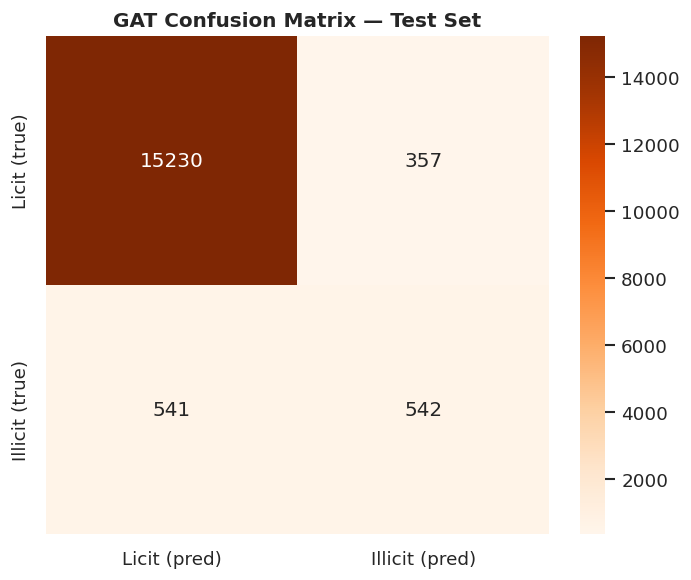

In [138]:
# ── Confusion matrix ──
cm = confusion_matrix(test_true_gat, preds_gat)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Licit (pred)','Illicit (pred)'],
            yticklabels=['Licit (true)','Illicit (true)'], ax=ax)
ax.set_title('GAT Confusion Matrix — Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('gat_confusion_matrix.png', bbox_inches='tight')
plt.show()


In [139]:
# ── 3-model comparison table ──
# Plug in your actual GCN and GraphSAGE numbers here
GCN_F1, GCN_PREC, GCN_REC, GCN_PRAUC       = 0.5045, 0.6353, 0.4183, 0.5103
SAGE_F1, SAGE_PREC, SAGE_REC, SAGE_PRAUC    = 0.5333, 0.4416, 0.6731, 0.6432

comparison = pd.DataFrame({
    'Model'      : ['GCN (Team 1 — baseline)',
                    'GraphSAGE (Team 2 — scalability)',
                    'GAT (Team 3 — explainability)'],
    'F1 (illicit)' : [GCN_F1,   SAGE_F1,  gat_f1   ],
    'Precision'    : [GCN_PREC, SAGE_PREC, gat_prec ],
    'Recall'       : [GCN_REC,  SAGE_REC,  gat_rec  ],
    'PR-AUC'       : [GCN_PRAUC,SAGE_PRAUC,gat_prauc],
})
print('Final Model Comparison:')
display(comparison.style
    .format({c:'{:.4f}' for c in comparison.columns[1:]})
    .highlight_max(subset=list(comparison.columns[1:]), color='#d4f7d4')
    .hide(axis='index'))


Final Model Comparison:


Model,F1 (illicit),Precision,Recall,PR-AUC
GCN (Team 1 — baseline),0.5045,0.6353,0.4183,0.5103
GraphSAGE (Team 2 — scalability),0.5333,0.4416,0.6731,0.6432
GAT (Team 3 — explainability),0.5469,0.6029,0.5005,0.5565


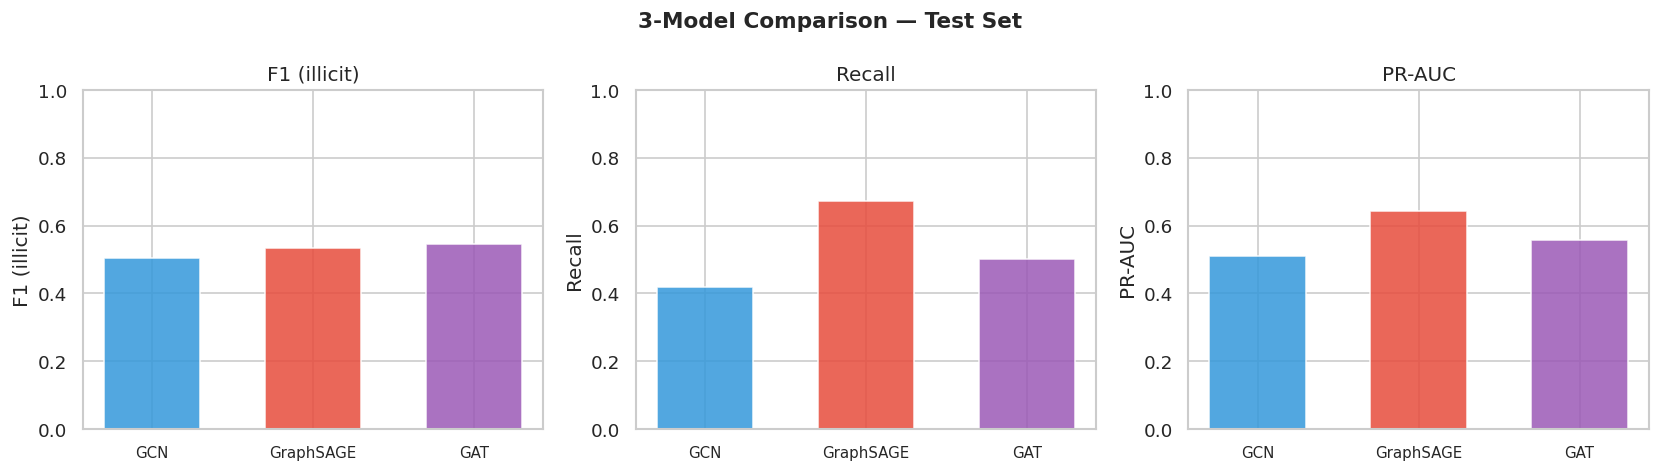

In [140]:
# ── Visual comparison: bar chart ──
models = ['GCN', 'GraphSAGE', 'GAT']
metrics = {
    'F1 (illicit)' : [GCN_F1,    SAGE_F1,  gat_f1   ],
    'Recall'       : [GCN_REC,   SAGE_REC,  gat_rec  ],
    'PR-AUC'       : [GCN_PRAUC, SAGE_PRAUC,gat_prauc],
}
colors = ['#3498DB', '#E74C3C', '#9B59B6']
x = np.arange(len(models)); w = 0.25

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (metric, vals) in zip(axes, metrics.items()):
    for j, (m, c) in enumerate(zip(models, colors)):
        ax.bar(x[j], vals[j], color=c, alpha=0.85, label=m, width=0.6)
    ax.set(title=metric, ylabel=metric, ylim=(0, 1))
    ax.set_xticks(x); ax.set_xticklabels(models, fontsize=9)

plt.suptitle('3-Model Comparison — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()


# Rolling Window (Incremental Learning)

Instead of training once on timesteps 1-34 and testing on 35-49,
we train incrementally:
1. Train on 1-34, test on 35
2. Expand training set to include timestep 35, fine-tune, test on 36
3. Repeat until timestep 49

This is applied to all three models.

In [141]:
import pandas as pd
import torch

# 1. Load the features file (it contains the timestep in the 2nd column)
# Replace 'path_to/elliptic_txs_features.csv' with your actual path
df_features = pd.read_csv("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv", header=None)

# 2. Extract the second column (index 1) which represents the timestep
# Note: Ensure the order of rows in the CSV matches the order in data_full.x
timesteps = torch.tensor(df_features[1].values, dtype=torch.long)

# 3. Attach it to your data object
data_full.time_steps = timesteps

print(f"Successfully attached time_steps. Unique steps: {data_full.time_steps.unique().tolist()}")

Successfully attached time_steps. Unique steps: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


In [142]:
import os
import torch
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score, classification_report

def rolling_window_evaluate_final(
    model, data, timestep_arr, model_name,
    pretrained_path=None,
    initial_epochs=1000,
    finetune_epochs=20,
    lr_init=1e-3,
    lr_ft=1e-4,
    weight_decay=5e-4,
    device=DEVICE
):
    print(f"\n{'='*50}")
    print(f"BENCHMARKING: {model_name}")
    print(f"{'='*50}")

    criterion = FocalLoss(alpha=0.85, gamma=2.0)
    if not isinstance(timestep_arr, torch.Tensor):
        timestep_arr = torch.tensor(timestep_arr)
    timestep_arr = timestep_arr.to(device)

    # ─────────────────────────────────────────────
    # Phase 1: Load Checkpoint or Train
    # ─────────────────────────────────────────────
    if pretrained_path and os.path.exists(pretrained_path):
        print(f"Loading saved checkpoint: {pretrained_path}")
        model.load_state_dict(torch.load(pretrained_path, map_location=device))
        print("Model weights loaded successfully.")
    else:
        print(f"No checkpoint found. Starting initial training (ts ≤ {TRAIN_TS_MAX})...")
        opt = torch.optim.Adam(model.parameters(), lr=lr_init, weight_decay=weight_decay)
        
        for ep in range(1, initial_epochs + 1):
            model.train()
            # Temporal graph for training
            train_nodes = torch.tensor(timestep_arr <= TRAIN_TS_MAX, dtype=torch.bool).to(device)
            edge_mask = (timestep_arr[data.edge_index[0]] <= TRAIN_TS_MAX) & \
                        (timestep_arr[data.edge_index[1]] <= TRAIN_TS_MAX)

            edge_index = data.edge_index[:, edge_mask].to(device)
            x, y = data.x.to(device), data.y.to(device)

            opt.zero_grad()
            out = model(x, edge_index)
            # Masking for training set nodes within the time limit
            mask = data.train_mask.to(device) & train_nodes
            loss = criterion(out[mask], y[mask])
            loss.backward()
            opt.step()
            
            if ep % 100 == 0:
                print(f"    Completed {ep}/{initial_epochs} epochs...")

    # ─────────────────────────────────────────────
    # Phase 2: Rolling Evaluation & Fine-tuning
    # ─────────────────────────────────────────────
    all_probs, all_preds, all_true, all_test_indices = [], [], [], []
    
    # Setup for replay buffer
    illicit_all = (data.y == 1).nonzero(as_tuple=True)[0]
    licit_all   = (data.y == 0).nonzero(as_tuple=True)[0]
    replay_illicit = illicit_all[data.train_mask[illicit_all]]

    for t in range(TEST_TS_START, TEST_TS_END + 1):
        # Build temporal graph G_t
        node_mask = torch.tensor(timestep_arr <= t, dtype=torch.bool).to(device)
        src, dst = data.edge_index
        edge_mask = (timestep_arr[src] <= t) & (timestep_arr[dst] <= t)
        edge_index = data.edge_index[:, edge_mask].to(device)
        x, y = data.x.to(device), data.y.to(device)

        ts_mask = (torch.tensor(timestep_arr == t).to(device)) & (y >= 0)
        if ts_mask.sum() == 0: continue

        # Evaluation
        model.eval()
        with torch.no_grad():
            logits = model(x, edge_index)
            probs = F.softmax(logits[ts_mask], dim=1)[:, 1].cpu().numpy()
            y_np = y[ts_mask].cpu().numpy()

            # Adaptive threshold logic
            best_thr = 0.5 if t < 43 else 0.3
            preds = (probs >= best_thr).astype(int)

            all_probs.append(probs)
            all_preds.append(preds)
            all_true.append(y_np)
            all_test_indices.extend(ts_mask.nonzero(as_tuple=False).view(-1).cpu().tolist())

        # Fine-tuning with Replay Buffer
        current_idx = ts_mask.nonzero(as_tuple=True)[0]
        buffer_size = 200
        illicit_sample = replay_illicit[torch.randperm(len(replay_illicit))[:buffer_size]]
        licit_sample = licit_all[torch.randperm(len(licit_all))[:buffer_size]]
        
        ft_idx = torch.cat([current_idx, illicit_sample, licit_sample]).to(device)
        ft_opt = torch.optim.Adam(model.parameters(), lr=lr_ft)
        ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ft_opt, T_max=finetune_epochs)

        model.train()
        for _ in range(finetune_epochs):
            ft_opt.zero_grad()
            edge_index_ft, _ = dropout_edge(edge_index, p=0.2)
            out = model(x, edge_index_ft)
            loss = criterion(out[ft_idx], y[ft_idx])
            loss.backward()
            ft_opt.step()
            ft_scheduler.step()

        # Update replay buffer for next timestep
        new_illicit = ((y == 1) & ts_mask).nonzero(as_tuple=True)[0]
        replay_illicit = torch.cat([replay_illicit, new_illicit])

    # ─────────────────────────────────────────────
    # Phase 3: Final Metrics & Return
    # ─────────────────────────────────────────────
    a_probs = np.concatenate(all_probs)
    a_preds = np.concatenate(all_preds)
    a_true  = np.concatenate(all_true)

    f1_mac = f1_score(a_true, a_preds, average='macro', zero_division=0)
    recall_illicit = recall_score(a_true, a_preds, pos_label=1, zero_division=0)

    print(f'\n{model_name} Final Results:')
    print(classification_report(a_true, a_preds, target_names=['Licit', 'Illicit']))
    
    return f1_mac, recall_illicit, a_true, a_preds, all_test_indices

# --- Main Benchmark Loop ---

models = {
    "gcn": GCN(in_channels=data_full.num_node_features).to(DEVICE),
    "graphsage_full": GraphSAGE(in_channels=data_full.num_node_features).to(DEVICE),
    "gat": GAT(in_channels=data_full.num_node_features,hidden_channels=64, out_channels=2,heads=4).to(DEVICE)
}

benchmark_results = {}
best_model_name, best_recall = None, 0

for name, model in models.items():
    ckpt_path = f"{name}_checkpoint.pt"
    
    f1, recall, t, p, indices = rolling_window_evaluate_final(
        model=model, 
        data=data_full, 
        timestep_arr=data_full.time_steps.cpu().numpy(), 
        model_name=name,
        pretrained_path=ckpt_path
    )
    
    benchmark_results[name] = {"F1": f1, "Recall": recall}
    
    if recall > best_recall:
        best_recall = recall
        best_model_name = name
        best_indices, best_targets, best_preds = indices, t, p

print(f"\nBest Architecture: {best_model_name} (Recall: {best_recall:.4f})")


BENCHMARKING: gcn
Loading saved checkpoint: gcn_checkpoint.pt
Model weights loaded successfully.

gcn Final Results:
              precision    recall  f1-score   support

       Licit       0.98      0.76      0.86     15587
     Illicit       0.18      0.76      0.29      1083

    accuracy                           0.76     16670
   macro avg       0.58      0.76      0.58     16670
weighted avg       0.93      0.76      0.82     16670


BENCHMARKING: graphsage_full
Loading saved checkpoint: graphsage_full_checkpoint.pt
Model weights loaded successfully.

graphsage_full Final Results:
              precision    recall  f1-score   support

       Licit       0.99      0.88      0.93     15587
     Illicit       0.32      0.83      0.46      1083

    accuracy                           0.87     16670
   macro avg       0.65      0.85      0.70     16670
weighted avg       0.94      0.87      0.90     16670


BENCHMARKING: gat
Loading saved checkpoint: gat_checkpoint.pt
Model weights 